#### Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import statsmodels.api as sm

from lifelines import KaplanMeierFitter, CoxPHFitter, NelsonAalenFitter
from sklearn.model_selection import KFold
from scipy.stats import gaussian_kde, norm
from sklearn.model_selection import train_test_split
from matplotlib.ticker import FuncFormatter
from lifelines.plotting import add_at_risk_counts
from lifelines.utils import concordance_index

from __future__ import annotations
from collections import Counter
from dataclasses import dataclass
import hashlib
import warnings
warnings.filterwarnings("ignore")

from dataclasses import dataclass
from typing import Optional, List, Dict, Tuple

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score
from lifelines.statistics import logrank_test
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None) 

#### Datasets

In [ ]:
lical0 = pd.read_csv('lical0_processed_data_for_fp_model_21-01-2026.csv')
miro0 = pd.read_csv('miro0_processed_data_for_fp_model_21-01-2026.csv')

proact0 = pd.read_csv('proact0_processed_data_for_fp_model_21-01-2026.csv')

MND_lica = pd.read_csv('MNDRegisterDataset_licals.csv')
MND_miro = pd.read_csv('MNDRegisterDataset_mirocals.csv')

In [4]:
lical0.head(2)

,subject_id,Event,Vital_capacity,Age_Onset,Diagnostic_Delay,Study_Duration,Age_Diag,Enrollment_Delay,ALSFRS_RT,ALSFRS_Rasch,slope,Disease_DurationD,Onset_site_Limb,Sex_Male,Study_Arm_Placebo
0,P01001,0,107.0,51.967146,5.880420,19.000000,52.457221,27.660972,35.0,25.7,-0.684211,30.958607,1,1,1
1,P01002,1,99.0,59.613963,9.526938,19.528252,60.407940,9.034166,43.0,32.2,-0.256039,27.562418,1,0,1


In [5]:
MND_lica.head(2)

,subject_id,Event,Disease_DurationD,Age_Onset,Age_Diag,Diagnostic_Delay,Sex_Male,Onset_Limb,slope,Enrollment_Delay
0,87,1,27.726675,67.43,68.290000,10.381078,1,1,-0.530175,143.00
1,1086,1,17.575558,64.43,64.739998,3.646518,0,0,-0.836389,252.27


In [6]:
proact0.head(2)

,subject_id,Event,Vital_capacity,Age_Onset,Age_Diag,Diagnostic_Delay,Study_Duration,slope,ALSFRS_Rasch,ALSFRS_RT,Enrollment_Delay,Disease_DurationD,Onset_site_Limb,Sex_Male,Study_Arm_Placebo
0,121,1,63.037137,50.997947,51.584887,7.042707,504.0,-1.196093,21.1,27.0,4.980946,22.538108,1,0,0
1,226,1,56.228941,70.743326,71.594689,10.215506,393.0,-1.581523,20.6,26.0,4.863338,18.773982,0,1,0


In [7]:
# proact0 = proact0[proact0['Disease_Duration'] < 120]
lical0 = lical0.rename(columns={'Onset_site_Limb': 'Onset_Limb'})
miro0 = miro0.rename(columns={'Onset_site_Limb': 'Onset_Limb'})
proact0 = proact0.rename(columns={'Onset_site_Limb': 'Onset_Limb'})

#### **Select only the treatment arm**

In [9]:
lical0_trt = lical0[lical0['Study_Arm_Placebo'] == 0].copy()
miro0_trt = miro0[miro0['Study_Arm_Placebo'] == 0].copy()
# miroli0_trt = miroli0[miroli0['Study_Arm_Placebo'] == 0].copy()
# ril_3010_trt = ril_3010[ril_3010['Study_Arm_Placebo'] == 0].copy()
proact0_trt = proact0[proact0['Study_Arm_Placebo'] == 0].copy() 

#### **Select only the placebo arm**

In [10]:
lical0_pla = lical0[lical0['Study_Arm_Placebo'] == 1].copy()
miro0_pla = miro0[miro0['Study_Arm_Placebo'] == 1].copy()
# miroli0_pla = miroli0[miroli0['Study_Arm_Placebo'] == 1].copy()
# ril_3010_pla = ril_3010[ril_3010['Study_Arm_Placebo'] == 1].copy()
proact0_pla = proact0[proact0['Study_Arm_Placebo'] == 1].copy() 

In [12]:
# MND_lica = MND_lica.rename(columns={'Enrollment_delay1':'Enrollment_Delay'})
# MND_miro = MND_miro.rename(columns={'Enrollment_delay1':'Enrollment_Delay'})

print(f"Miro: {miro0_pla.Disease_DurationD.describe().round(2).to_dict()}\n")
# print(f"miroli: {miroli0_pla.Study_Duration.describe().round(2).to_dict()}\n")
print(f"Lical :{lical0_pla.Disease_DurationD.describe().round(2).to_dict()}\n")
# print(f"Riluzole: {ril_3010_pla.Study_Duration.describe().round(2).to_dict()}\n")

print(f"Proact: {proact0_pla.Disease_DurationD.describe().round(2).to_dict()}\n")

print(f"MND_lica: {MND_lica.Disease_DurationD.describe().round(2).to_dict()}\n")
print(f"MND_miro: {MND_miro.Disease_DurationD.describe().round(2).to_dict()}\n")
# print(f"MND_rilu: {MND_rilu.Study_Duration.describe().round(2).to_dict()}\n")

Miro: {'count': 110.0, 'mean': 19.99, 'std': 5.91, 'min': 4.02, '25%': 15.83, '50%': 22.58, '75%': 23.52, 'max': 33.98}

Lical :{'count': 107.0, 'mean': 21.56, 'std': 6.21, 'min': 3.32, '25%': 19.29, '50%': 21.96, '75%': 26.08, 'max': 32.52}

Proact: {'count': 1490.0, 'mean': 20.95, 'std': 10.24, 'min': 1.66, '25%': 13.82, '50%': 18.88, '75%': 26.19, 'max': 84.08}

MND_lica: {'count': 120.0, 'mean': 18.98, 'std': 7.67, 'min': 6.04, '25%': 12.89, '50%': 19.14, '75%': 24.88, 'max': 33.97}

MND_miro: {'count': 114.0, 'mean': 15.52, 'std': 7.41, 'min': 1.91, '25%': 8.86, '50%': 16.02, '75%': 21.85, 'max': 27.92}



#### **Choosing cohorts**

In [13]:
# MND_lica.columns

In [14]:
lical0_trt.columns

Index(['subject_id', 'Event', 'Vital_capacity', 'Age_Onset',
       'Diagnostic_Delay', 'Study_Duration', 'Age_Diag', 'Enrollment_Delay',
       'ALSFRS_RT', 'ALSFRS_Rasch', 'slope', 'Disease_DurationD', 'Onset_Limb',
       'Sex_Male', 'Study_Arm_Placebo'],
      dtype='object')

In [15]:
MND_miro['Study_Arm_Placebo'] = 1
MND_lica['Study_Arm_Placebo'] = 1

# MND_miro = MND_miro.rename(columns={'TRICALS_Risk_Score': 'TRICALS'})
# MND_lica = MND_lica.rename(columns={'TRICALS_Risk_Score': 'TRICALS'})
MND_lica.head(2)

,subject_id,Event,Disease_DurationD,Age_Onset,Age_Diag,Diagnostic_Delay,Sex_Male,Onset_Limb,slope,Enrollment_Delay,Study_Arm_Placebo
0,87,1,27.726675,67.43,68.290000,10.381078,1,1,-0.530175,143.00,1
1,1086,1,17.575558,64.43,64.739998,3.646518,0,0,-0.836389,252.27,1


In [16]:
miro0_trt.head(2)

,subject_id,Event,Vital_capacity,Age_Onset,Diagnostic_Delay,Study_Duration,Age_Diag,Enrollment_Delay,ALSFRS_RT,ALSFRS_Rasch,slope,Disease_DurationD,Onset_Limb,Sex_Male,Study_Arm_Placebo
1,1-62479,1,81.0,63.754,15.600,5.500657,65.054,4.044,25.0,20.1,-4.181319,9.544657,0,0,0
2,1-62480,0,96.0,56.167,8.904,22.024967,56.909,1.380,42.0,31.1,-0.272418,23.404967,1,1,0


In [17]:
miro0_trt_for_mnd_data = miro0_trt[['subject_id', 'Event', 'Disease_DurationD','Study_Arm_Placebo', 'Age_Diag', 'Diagnostic_Delay', 'Sex_Male', 'Onset_Limb', 'Enrollment_Delay']]
lica0_trt_for_mnd_data = lical0_trt[['subject_id', 'Event', 'Disease_DurationD','Study_Arm_Placebo', 'Age_Diag', 'Diagnostic_Delay', 'Sex_Male', 'Onset_Limb', 'Enrollment_Delay']]

miro0_pla_for_mnd_data = miro0_pla[['subject_id', 'Event', 'Disease_DurationD','Study_Arm_Placebo', 'Age_Diag', 'Diagnostic_Delay', 'Sex_Male', 'Onset_Limb', 'Enrollment_Delay']]
lica0_pla_for_mnd_data = lical0_pla[['subject_id', 'Event', 'Disease_DurationD','Study_Arm_Placebo', 'Age_Diag', 'Diagnostic_Delay', 'Sex_Male', 'Onset_Limb', 'Enrollment_Delay']]

MND_lica = MND_lica[['subject_id', 'Event', 'Disease_DurationD','Study_Arm_Placebo', 'Age_Diag', 'Diagnostic_Delay', 'Sex_Male', 'Onset_Limb', 'Enrollment_Delay']]
MND_miro = MND_miro[['subject_id', 'Event', 'Disease_DurationD','Study_Arm_Placebo', 'Age_Diag', 'Diagnostic_Delay', 'Sex_Male', 'Onset_Limb', 'Enrollment_Delay']]
# miro_trt_trical = miro0_trt[(miro0_trt['TRICALS'] >= -6) & (miro0_trt['TRICALS'] <= -2)]
# MND_miro_trical = MND_miro[(MND_miro['TRICALS'] >= -6) & (MND_miro['TRICALS'] <= -2)]

# lica_trt_trical = lical0_trt[(lical0_trt['TRICALS'] >= -6) & (lical0_trt['TRICALS'] <= -2)]
# MND_lica_trical = MND_lica[(MND_lica['TRICALS'] >= -6) & (MND_lica['TRICALS'] <= -2)]


In [18]:
MND_lica.head(2)

,subject_id,Event,Disease_DurationD,Study_Arm_Placebo,Age_Diag,Diagnostic_Delay,Sex_Male,Onset_Limb,Enrollment_Delay
0,87,1,27.726675,1,68.290000,10.381078,1,1,143.00
1,1086,1,17.575558,1,64.739998,3.646518,0,0,252.27


#### **Propensity score matching**

In [19]:
# ============================================================
# PROPENSITY SCORE + OVERLAP
# ============================================================
def fit_ps_trim_weight(
    df: pd.DataFrame,
    covariates: List[str],
    penalty: str = "l2",
    C: float = 1.0,
    trim: bool = True,
    weight_method: str = "overlap",
    ps_col: str = "ps",
    group_col: str = "Group",
    verbose: bool = True
) -> Tuple[pd.DataFrame, Pipeline]:
    """
    Fit a logistic-regression propensity score model, optionally trim to common
    support, and add balancing weights.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe containing covariates and treatment/group indicator.
    covariates : List[str]
        Covariates used in the propensity score model.
    penalty : str, default="l2"
        LogisticRegression penalty.
    C : float, default=1.0
        Inverse regularization strength for LogisticRegression.
    trim : bool, default=True
        If True, trim observations outside the common support region.
    weight_method : str, default="overlap"
        Weighting scheme. Supported:
        - "overlap"
        - "iptw"
        - "unstabilized"
    ps_col : str, default="ps"
        Name of the propensity score column to create/use.
    group_col : str, default="Group"
        Name of binary treatment/group column (0 = control, 1 = treated).
    verbose : bool, default=True
        If True, print AUC and trimming summary.

    Returns
    -------
    Tuple[pd.DataFrame, Pipeline]
        Processed dataframe and fitted sklearn pipeline.
    """
    # -----------------------------
    # Validate inputs
    # -----------------------------
    required_cols = set(covariates + [group_col])
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    x = df[covariates].copy()
    y = df[group_col].astype(int).values

    if not set(np.unique(y)).issubset({0, 1}):
        raise ValueError(f"{group_col} must be binary with values 0/1.")

    # -----------------------------
    # Build and fit PS model
    # -----------------------------
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, covariates)
        ],
        remainder="drop"
    )

    model = LogisticRegression(
        penalty=penalty,
        C=C,
        solver="lbfgs",
        max_iter=5000
    )

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(x, y)
    ps = pipe.predict_proba(x)[:, 1]
    ps_clipped = np.clip(ps, 1e-6, 1 - 1e-6)

    out = df.copy()
    out[ps_col] = ps
    out["ps_logit"] = np.log(ps_clipped / (1 - ps_clipped))

    auc = roc_auc_score(y, ps)
    if verbose:
        print(f"Propensity model AUC: {auc:.3f}")

    # -----------------------------
    # Optional trimming
    # -----------------------------
    if trim:
        ps_t = out.loc[out[group_col] == 1, ps_col]
        ps_c = out.loc[out[group_col] == 0, ps_col]

        lower_common = max(ps_t.min(), ps_c.min())
        upper_common = min(ps_t.max(), ps_c.max())

        before_n = len(out)
        out = out[(out[ps_col] >= lower_common) & (out[ps_col] <= upper_common)].copy()
        out = out.reset_index(drop=True)

        if verbose:
            print(f"Before trimming: {before_n}")
            print(f"After trimming:  {len(out)}")
            print(f"Removed:         {before_n - len(out)}")

    # -----------------------------
    # Add weights
    # -----------------------------
    ps_final = np.clip(out[ps_col].values, 1e-6, 1 - 1e-6)
    g = out[group_col].astype(int).values

    if weight_method == "overlap":
        w = np.where(g == 1, 1 - ps_final, ps_final)
    elif weight_method in ("iptw", "unstabilized"):
        w = np.where(g == 1, 1 / ps_final, 1 / (1 - ps_final))
    else:
        raise ValueError("weight_method must be 'overlap' or 'iptw'")

    out["weight"] = w

    return out, pipe




# ============================================================
# BALANCE DIAGNOSTICS
# ============================================================
def weighted_mean(x, w):
    return np.sum(w * x) / np.sum(w)


def weighted_var(x, w):
    mu = weighted_mean(x, w)
    return np.sum(w * (x - mu) ** 2) / np.sum(w)


def smd_continuous(x_t, x_c, w_t=None, w_c=None):
    x_t = np.asarray(x_t, dtype=float)
    x_c = np.asarray(x_c, dtype=float)

    if w_t is None:
        mt = np.nanmean(x_t)
        vt = np.nanvar(x_t, ddof=0)
    else:
        mt = weighted_mean(x_t, w_t)
        vt = weighted_var(x_t, w_t)

    if w_c is None:
        mc = np.nanmean(x_c)
        vc = np.nanvar(x_c, ddof=0)
    else:
        mc = weighted_mean(x_c, w_c)
        vc = weighted_var(x_c, w_c)

    pooled_sd = np.sqrt((vt + vc) / 2)
    if pooled_sd == 0 or np.isnan(pooled_sd):
        return np.nan
    return (mt - mc) / pooled_sd


def smd_binary(x_t, x_c, w_t=None, w_c=None):
    x_t = np.asarray(x_t, dtype=float)
    x_c = np.asarray(x_c, dtype=float)

    if w_t is None:
        pt = np.nanmean(x_t)
    else:
        pt = weighted_mean(x_t, w_t)

    if w_c is None:
        pc = np.nanmean(x_c)
    else:
        pc = weighted_mean(x_c, w_c)

    p = (pt + pc) / 2
    denom = np.sqrt(p * (1 - p))
    if denom == 0 or np.isnan(denom):
        return np.nan
    return (pt - pc) / denom


def balance_table(df: pd.DataFrame, covariates: List[str], weight_col: Optional[str] = None) -> pd.DataFrame:
    rows = []

    treated = df[df["Group"] == 1].copy()
    control = df[df["Group"] == 0].copy()

    for col in covariates:
        xt = treated[col].astype(float)
        xc = control[col].astype(float)

        mask_t = xt.notna()
        mask_c = xc.notna()
        xt = xt[mask_t]
        xc = xc[mask_c]

        wt = treated.loc[mask_t, weight_col].values if weight_col is not None else None
        wc = control.loc[mask_c, weight_col].values if weight_col is not None else None

        uniq = pd.concat([xt, xc]).dropna().unique()
        is_binary = set(np.unique(uniq)).issubset({0.0, 1.0})

        if is_binary:
            smd = smd_binary(xt, xc, wt, wc)
        else:
            smd = smd_continuous(xt, xc, wt, wc)

        if weight_col is None:
            mt = np.nanmean(xt)
            mc = np.nanmean(xc)
        else:
            mt = weighted_mean(xt.values, wt)
            mc = weighted_mean(xc.values, wc)

        rows.append({
            "Variable": col,
            "Treated_mean": mt,
            "Control_mean": mc,
            "SMD": smd,
            "Abs_SMD": np.abs(smd)
        })

    out = pd.DataFrame(rows).sort_values("Abs_SMD", ascending=False).reset_index(drop=True)
    return out


# ============================================================
# SURVIVAL ANALYSIS
# ============================================================
def weighted_km_plot(
    df: pd.DataFrame,
    time_col: str = "Time",
    event_col: str = "Event",
    weight_col: Optional[str] = "weight",
    title: str = "Weighted Kaplan-Meier",
    x_max: Optional[float] = None
):
    plt.figure(figsize=(5, 4))

    km_t = KaplanMeierFitter()
    km_c = KaplanMeierFitter()

    treated = df[df["Group"] == 1].copy()
    control = df[df["Group"] == 0].copy()

    km_t.fit(
        durations=treated[time_col],
        event_observed=treated[event_col],
        weights=treated[weight_col] if weight_col else None,
        label="Treated"
    )
    km_c.fit(
        durations=control[time_col],
        event_observed=control[event_col],
        weights=control[weight_col] if weight_col else None,
        label="External control"
    )

    ax = km_t.plot_survival_function(ci_show=True)
    km_c.plot_survival_function(ci_show=True, ax=ax)

    ax.set_xlabel("Disease Duration")
    ax.set_ylabel("Survival probability")
    ax.set_title(title)
    ax.set_ylim(0,1.02)
    ax.grid(True, alpha=0.3)
    if x_max is not None:
        ax.set_xlim(0, x_max)
    plt.tight_layout()
    plt.show()
    


#### **Prepare data**

In [20]:
# combine treated and  placebo patients
# lical and MND_lical
lica0_trt_for_mnd_data['data'] = "lical0_trt"
MND_lica['data'] = "MND_lica"
comb_mnd_lica_trt = pd.concat([lica0_trt_for_mnd_data, MND_lica], axis=0, ignore_index=True)
comb_mnd_lica_trt['Group'] = (comb_mnd_lica_trt['Study_Arm_Placebo'] == 0).astype(int)

lica0_pla_for_mnd_data['data'] = "lical0_pla"
MND_lica['data'] = "MND_lica"
comb_mnd_lica_pla = pd.concat([lica0_pla_for_mnd_data, MND_lica], axis=0, ignore_index=True)
comb_mnd_lica_pla['Group'] = (comb_mnd_lica_pla['data'] == "lical0_pla").astype(int)

# mirocal and MND_mirocal
miro0_trt_for_mnd_data['data'] = "miro0_trt"
MND_miro['data'] = "MND_miro"
comb_mnd_miro_trt = pd.concat([miro0_trt_for_mnd_data, MND_miro], axis=0, ignore_index=True)
comb_mnd_miro_trt['Group'] = (comb_mnd_miro_trt['Study_Arm_Placebo'] == 0).astype(int)

miro0_pla_for_mnd_data['data'] = "miro0_pla"
MND_miro['data'] = "MND_miro"
comb_mnd_miro_pla = pd.concat([miro0_pla_for_mnd_data, MND_miro], axis=0, ignore_index=True)
comb_mnd_miro_pla['Group'] = (comb_mnd_miro_pla['data'] == "miro0_pla").astype(int)


# # lical and proact_lical
# lical0_trt['data'] = "lical0_trt"
# proact_lica_pla['data'] = "proact_lica_pla"
# comb_proact_lica_trt = pd.concat([lical0_trt, proact_lica_pla], axis=0, ignore_index=True)
# comb_proact_lica_trt['Group'] = (comb_proact_lica_trt['Study_Arm_Placebo'] == 0).astype(int)

# lical0_pla['data'] = "lical0_pla"
# proact_lica_pla['data'] = "proact_lica_pla"
# comb_proact_lica_pla = pd.concat([lical0_pla, proact_lica_pla], axis=0, ignore_index=True)
# comb_proact_lica_pla['Group'] = (comb_proact_lica_pla['data'] == "lical0_pla").astype(int)

# # mirocal and MND_mirocal
# miro0_trt['data'] = "miro0_trt"
# proact_miro_pla['data'] = "proact_miro_pla"
# comb_proact_miro_trt = pd.concat([miro0_trt, proact_miro_pla], axis=0, ignore_index=True)
# comb_proact_miro_trt['Group'] = (comb_proact_miro_trt['Study_Arm_Placebo'] == 0).astype(int)

# miro0_pla['data'] = "miro0_pla"
# proact_miro_pla['data'] = "proact_miro_pla"
# comb_proact_miro_pla = pd.concat([miro0_pla, proact_miro_pla], axis=0, ignore_index=True)
# comb_proact_miro_pla['Group'] = (comb_proact_miro_pla['data'] == "miro0_pla").astype(int)



# # proact_mirocal and MND_mirocal
# proact_miro_trt['data'] = "proact_miro_trt"
# MND_miro['data'] = "MND_miro"
# comb_mnd_proact_miro_trt = pd.concat([proact_miro_trt, MND_miro], axis=0, ignore_index=True)
# comb_mnd_proact_miro_trt['Group'] = (comb_mnd_proact_miro_trt['Study_Arm_Placebo'] == 0).astype(int)

# proact_miro_pla['data'] = "proact_miro_pla"
# MND_miro['data'] = "MND_miro"
# comb_mnd_proact_miro_pla = pd.concat([proact_miro_pla, MND_miro], axis=0, ignore_index=True)
# comb_mnd_proact_miro_pla['Group'] = (comb_mnd_proact_miro_pla['data'] == "proact_miro_pla").astype(int)


# # proact_lical and MND_lical
# proact_lica_trt['data'] = "proact_lica_trt"
# MND_lica['data'] = "MND_lica"
# comb_mnd_proact_lica_trt = pd.concat([proact_lica_trt, MND_lica], axis=0, ignore_index=True)
# comb_mnd_proact_lica_trt['Group'] = (comb_mnd_proact_lica_trt['Study_Arm_Placebo'] == 0).astype(int)

# proact_lica_pla['data'] = "proact_lica_pla"
# MND_lica['data'] = "MND_lica"
# comb_mnd_proact_lica_pla = pd.concat([proact_lica_pla, MND_lica], axis=0, ignore_index=True)
# comb_mnd_proact_lica_pla['Group'] = (comb_mnd_proact_lica_pla['data'] == "proact_lica_pla").astype(int)

In [21]:
def log_transform_and_standardize_columns(df, cols):
    for col in cols:
        df[col + "_l"] = np.log1p(df[col])  # ln(1 + x)
    
    for col in df.select_dtypes(include=['float']).columns:
        df[col + '_std'] = (df[col] - df[col].mean()) / df[col].std()
    return df

cols_to_transform = ['Disease_DurationD', 'Diagnostic_Delay', 'Enrollment_Delay']

comb_mnd_lica_trt = log_transform_and_standardize_columns(comb_mnd_lica_trt, cols_to_transform)
comb_mnd_miro_trt = log_transform_and_standardize_columns(comb_mnd_miro_trt, cols_to_transform)
comb_mnd_lica_pla = log_transform_and_standardize_columns(comb_mnd_lica_pla, cols_to_transform)
comb_mnd_miro_pla = log_transform_and_standardize_columns(comb_mnd_miro_pla, cols_to_transform)

comb_mnd_lica_trt.head(2)

,subject_id,Event,Disease_DurationD,Study_Arm_Placebo,Age_Diag,Diagnostic_Delay,Sex_Male,Onset_Limb,Enrollment_Delay,data,Group,Disease_DurationD_l,Diagnostic_Delay_l,Enrollment_Delay_l,Disease_DurationD_std,Age_Diag_std,Diagnostic_Delay_std,Enrollment_Delay_std,Disease_DurationD_l_std,Diagnostic_Delay_l_std,Enrollment_Delay_l_std
0,P01003,0,27.949409,0,45.568789,4.960578,1,1,13.600526,lical0_trt,1,3.365550,1.785167,2.681058,1.107979,-1.018544,-0.861472,-0.986832,0.973755,-1.204359,-0.644340
1,P01004,0,26.402431,0,46.535250,2.660972,1,1,7.884363,lical0_trt,1,3.310632,1.297729,2.184293,0.896095,-0.935835,-1.148480,-1.031471,0.840898,-2.141968,-0.914845


In [22]:
comb_mnd_lica_trt.columns

Index(['subject_id', 'Event', 'Disease_DurationD', 'Study_Arm_Placebo',
       'Age_Diag', 'Diagnostic_Delay', 'Sex_Male', 'Onset_Limb',
       'Enrollment_Delay', 'data', 'Group', 'Disease_DurationD_l',
       'Diagnostic_Delay_l', 'Enrollment_Delay_l', 'Disease_DurationD_std',
       'Age_Diag_std', 'Diagnostic_Delay_std', 'Enrollment_Delay_std',
       'Disease_DurationD_l_std', 'Diagnostic_Delay_l_std',
       'Enrollment_Delay_l_std'],
      dtype='object')

In [23]:
comb_mnd_lica_trt = comb_mnd_lica_trt[['subject_id', 'Event', 'Disease_DurationD','Study_Arm_Placebo', 'Age_Diag_std', 'Diagnostic_Delay_l_std', 'Sex_Male', 'Onset_Limb', 'Enrollment_Delay_l_std', 'data', 'Group']]
comb_mnd_miro_trt = comb_mnd_miro_trt[['subject_id', 'Event', 'Disease_DurationD','Study_Arm_Placebo', 'Age_Diag_std', 'Diagnostic_Delay_l_std', 'Sex_Male', 'Onset_Limb', 'Enrollment_Delay_l_std', 'data', 'Group']]
comb_mnd_lica_pla = comb_mnd_lica_pla[['subject_id', 'Event', 'Disease_DurationD','Study_Arm_Placebo', 'Age_Diag_std', 'Diagnostic_Delay_l_std', 'Sex_Male', 'Onset_Limb', 'Enrollment_Delay_l_std', 'data', 'Group']]
comb_mnd_miro_pla = comb_mnd_miro_pla[['subject_id', 'Event', 'Disease_DurationD','Study_Arm_Placebo', 'Age_Diag_std', 'Diagnostic_Delay_l_std', 'Sex_Male', 'Onset_Limb', 'Enrollment_Delay_l_std', 'data', 'Group']]

comb_mnd_lica_trt = comb_mnd_lica_trt.rename(columns={'Disease_DurationD': 'Disease_Duration', 'Diagnostic_Delay_l_std': 'Diagnostic_Delay', 'Enrollment_Delay_l_std':'Enrollment_Delay', 'Age_Diag_std': 'Age'})
comb_mnd_miro_trt = comb_mnd_miro_trt.rename(columns={'Disease_DurationD': 'Disease_Duration', 'Diagnostic_Delay_l_std': 'Diagnostic_Delay', 'Enrollment_Delay_l_std':'Enrollment_Delay', 'Age_Diag_std': 'Age'})
comb_mnd_lica_pla = comb_mnd_lica_pla.rename(columns={'Disease_DurationD': 'Disease_Duration', 'Diagnostic_Delay_l_std': 'Diagnostic_Delay', 'Enrollment_Delay_l_std':'Enrollment_Delay', 'Age_Diag_std': 'Age'})
comb_mnd_miro_pla = comb_mnd_miro_pla.rename(columns={'Disease_DurationD': 'Disease_Duration', 'Diagnostic_Delay_l_std': 'Diagnostic_Delay', 'Enrollment_Delay_l_std':'Enrollment_Delay', 'Age_Diag_std': 'Age'})

comb_mnd_lica_trt.head(2)

,subject_id,Event,Disease_Duration,Study_Arm_Placebo,Age,Diagnostic_Delay,Sex_Male,Onset_Limb,Enrollment_Delay,data,Group
0,P01003,0,27.949409,0,-1.018544,-1.204359,1,1,-0.644340,lical0_trt,1
1,P01004,0,26.402431,0,-0.935835,-2.141968,1,1,-0.914845,lical0_trt,1


In [27]:
comb_mnd_lica_trt['Diagnostic_Delay'].corr(comb_mnd_lica_trt['Disease_Duration'])

np.float64(0.07252857054494724)

 **comb_mnd_lica_trt, comb_mnd_lica_pla, comb_mnd_miro_trt, comb_mnd_miro_pla**

 **comb_proact_lica_trt,  comb_proact_lica_pla, comb_proact_miro_trt, comb_proact_miro_pla**
 
 **comb_mnd_proact_miro_trt, comb_mnd_proact_miro_pla,  comb_mnd_proact_lica_trt, comb_mnd_proact_lica_pla**

In [28]:
covariates = ['Disease_Duration', 'Age', 'Diagnostic_Delay', 'Onset_Limb', 'Sex_Male']

df_mnd_lica_trt, ps_mnd_lica_trt = fit_ps_trim_weight(df=comb_mnd_lica_trt, covariates=covariates, trim=True, weight_method="overlap")
df_mnd_lica_pla, ps_mnd_lica_pla = fit_ps_trim_weight(df=comb_mnd_lica_pla, covariates=covariates, trim=True, weight_method="overlap")
df_mnd_miro_trt, ps_mnd_miro_trt = fit_ps_trim_weight(df=comb_mnd_miro_trt, covariates=covariates, trim=True, weight_method="overlap")
df_mnd_miro_pla, ps_mnd_miro_pla = fit_ps_trim_weight(df=comb_mnd_miro_pla, covariates=covariates, trim=True, weight_method="overlap")

# df_proact_lica_trt, ps_proact_lica_trt = fit_ps_trim_weight(df=comb_proact_lica_trt, covariates=covariates, trim=True, weight_method="overlap")
# df_proact_lica_pla, ps_proact_lica_pla = fit_ps_trim_weight(df=comb_proact_lica_pla, covariates=covariates, trim=True, weight_method="overlap")
# df_proact_miro_trt, ps_proact_miro_trt = fit_ps_trim_weight(df=comb_proact_miro_trt, covariates=covariates, trim=True, weight_method="overlap")
# df_proact_miro_pla, ps_proact_miro_pla = fit_ps_trim_weight(df=comb_proact_miro_pla, covariates=covariates, trim=True, weight_method="overlap")

# df_mnd_proact_miro_trt, ps_mnd_proact_miro_trt = fit_ps_trim_weight(df=comb_mnd_proact_miro_trt, covariates=covariates, trim=True, weight_method="overlap")
# df_mnd_proact_miro_pla, ps_mnd_proact_miro_pla = fit_ps_trim_weight(df=comb_mnd_proact_miro_pla, covariates=covariates, trim=True, weight_method="overlap")
# df_mnd_proact_lica_trt, ps_mnd_proact_lica_trt = fit_ps_trim_weight(df=comb_mnd_proact_lica_trt, covariates=covariates, trim=True, weight_method="overlap")
# df_mnd_proact_lica_pla, ps_mnd_proact_lica_pla = fit_ps_trim_weight(df=comb_mnd_proact_lica_pla, covariates=covariates, trim=True, weight_method="overlap")

Propensity model AUC: 0.639
Before trimming: 227
After trimming:  222
Removed:         5
Propensity model AUC: 0.641
Before trimming: 227
After trimming:  210
Removed:         17
Propensity model AUC: 0.721
Before trimming: 224
After trimming:  216
Removed:         8
Propensity model AUC: 0.701
Before trimming: 224
After trimming:  210
Removed:         14


In [29]:
df_mnd_miro_trt.head(2)

,subject_id,Event,Disease_Duration,Study_Arm_Placebo,Age,Diagnostic_Delay,Sex_Male,Onset_Limb,Enrollment_Delay,data,Group,ps,ps_logit,weight
0,1-62479,1,9.544657,0,0.709187,0.949007,0,0,-0.729832,miro0_trt,1,0.223511,-1.245325,0.776489
1,1-62480,0,23.404967,0,-0.013367,-0.006095,1,1,-1.060684,miro0_trt,1,0.647812,0.609436,0.352188


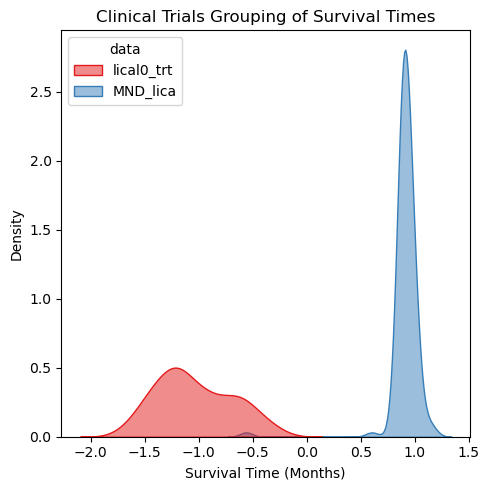

In [30]:
# create side-by-side plot
fig, ax = plt.subplots(figsize=(5, 5))

# --- Plot 1: KDE plot ---
sns.kdeplot(data=df_mnd_lica_trt, x='Enrollment_Delay', hue='data', fill=True, alpha=0.5, palette='Set1', ax=ax)
ax.set_title("Clinical Trials Grouping of Survival Times")
ax.set_xlabel("Survival Time (Months)")
ax.set_ylabel("Density")
# ax.legend(title="Clinical Trials Cluster")
plt.tight_layout()
plt.show()

In [31]:
df_mnd_miro_trt[df_mnd_miro_trt['data'] == 'miro0_trt']['Enrollment_Delay'].describe()
df_mnd_miro_trt[df_mnd_miro_trt['data'] == 'MND_miro']['Enrollment_Delay'].describe()

count    111.000000
mean       0.968770
std        0.058964
min        0.746519
25%        0.941624
50%        0.953513
75%        0.984366
max        1.203105
Name: Enrollment_Delay, dtype: float64

#### **checks**

In [ ]:
# ============================================================
# BALANCE DIAGNOSTICS
# ============================================================
# comb_baln = balance_table(df_ps, covariates, 'weight')
# comb_baln

In [ ]:
# weighted_km_plot(comb_weight, time_col = "Disease_Duration", event_col = "Event",weight_col = None)

In [ ]:
# weighted_km_plot(comb_weight, time_col = "Disease_Duration", event_col = "Event",weight_col = "weight")

#### **Helper function**

In [32]:
# ============================================================
# Basic helpers
# ============================================================
def weighted_mean_np(x: np.ndarray, w: np.ndarray | None = None) -> float:
    x = np.asarray(x, float)
    if w is None:
        return float(np.mean(x))
    w = np.asarray(w, float)
    ok = np.isfinite(x) & np.isfinite(w) & (w > 0)
    if not np.any(ok):
        return np.nan
    return float(np.sum(w[ok] * x[ok]) / np.sum(w[ok]))


def _logit(p: float) -> float:
    p = float(np.clip(p, 1e-12, 1 - 1e-12))
    return float(np.log(p / (1 - p)))


def ci_str(lo, hi, digits=3):
    if lo is None or hi is None or (not np.isfinite(lo)) or (not np.isfinite(hi)):
        return ""
    return f"[{lo:.{digits}f}, {hi:.{digits}f}]"



# ============================================================
# Data prep
# ============================================================
def build_analysis_df(
    df: pd.DataFrame,
    covariates: list[str],
    weight_col: str | None = "weight",
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
) -> pd.DataFrame:
    needed = [time_col, event_col] + list(covariates)
    if weight_col is not None and weight_col in df.columns:
        needed += [weight_col]

    out = df.loc[:, needed].copy()

    for c in [time_col, event_col] + list(covariates):
        out[c] = pd.to_numeric(out[c], errors = "coerce")

    if weight_col is not None and weight_col in out.columns:
        out[weight_col] = pd.to_numeric(out[weight_col], errors="coerce")

    out = out.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

    if weight_col is not None and weight_col in out.columns:
        out = out[np.isfinite(out[weight_col]) & out[weight_col] > 0].reset_index(drop=True)

    out[event_col] = out[event_col].astype(int)
    return out


def prep_df(
    df: pd.DataFrame,
    covariates: list[str],
    weight_col: str | None = "weight",
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
) -> pd.DataFrame:
    return build_analysis_df(df, covariates, weight_col, time_col, event_col)



# ============================================================
# KM helpers
# ============================================================
def km_surv_at_t0(
    df: pd.DataFrame,
    t0_months: float,
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    weight_col: str | None = "weight",
) -> float:
    kmf = KaplanMeierFitter()
    if weight_col is not None and weight_col in df.columns:
        kmf.fit(df[time_col],  event_observed=df[event_col], weights = df[weight_col])
    else:
        kmf.fit(df[time_col], event_observed=df[event_col])

    surv = kmf.predict(t0_months)
    return float(surv) if np.isfinite(surv) else np.nan


def km_risk_ci_at_t0(
    df: pd.DataFrame,
    t0_months: float,
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    weight_col: str | None = "weight",
):
    kmf = KaplanMeierFitter()
    if weight_col is not None and weight_col in df.columns:
        kmf.fit(df[time_col], event_observed=df[event_col], weights = df[weight_col])
    else:
        kmf.fit(df[time_col], event_observed=df[event_col])

    times = kmf.survival_function_.index.to_numpy()
    times = times[times <= t0_months]
    if len(times) == 0:
        return np.nan, np.nan, np.nan

    t_use = float(np.max(times))
    s = float(kmf.predict(t_use))
    ci = kmf.confidence_interval_survival_function_

    lo_ci = ci.columns[0]
    hi_ci = ci.columns[1]
    lo = float(ci.loc[t_use, lo_ci])
    hi = float(ci.loc[t_use, hi_ci])

    risk = 1 - s
    risk_lo = 1 - hi
    risk_hi = 1 - lo

    return float(risk), float(risk_lo), float(risk_hi)



# ============================================================
# Cox fitting
# ============================================================
def fit_cox_model(
    df: pd.DataFrame,
    covariates: list[str],
    weight_col: str | None = "weight",
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    robust: bool = True,
):
    dat = build_analysis_df(df, covariates, weight_col, time_col, event_col)

    cph = CoxPHFitter()
    fit_kwargs = dict(duration_col=time_col, event_col=event_col, robust = robust)

    if weight_col is not None and weight_col in dat.columns:
        fit_kwargs["weights_col"] = weight_col

    cph.fit(dat, **fit_kwargs)
    return cph, dat



# ============================================================
# Prediction helpers
# ============================================================
def predict_lp_from_cox(
    model: CoxPHFitter,
    df: pd.DataFrame,
    covariates: list[str],
) -> np.ndarray:
    return model.predict_log_partial_hazard(df[covariates]).to_numpy().reshape(-1)


def predict_surv_at_t0(
    model: CoxPHFitter,
    df: pd.DataFrame,
    covariates: list[str],
    t0_months: float,
) -> np.ndarray:
    surv_df = model.predict_survival_function(df[covariates], times=[t0_months])
    return surv_df.loc[t0_months].to_numpy(dtype=float)


# ============================================================
# Score sign helpers
# ============================================================
def choose_score_sign_from_lp(
    lp: np.ndarray,
    event: np.ndarray,
    weights: np.ndarray | None = None,
) -> int:
    lp = np.asarray(lp, float)
    event = np.asarray(event).astype(bool)

    if weights is None:
        m1 = float(np.mean(lp[event])) if np.any(event) else np.nan
        m0 = float(np.mean(lp[~event])) if np.any(~event) else np.nan
    else:
        w = np.asarray(weights, float)
        m1 = weighted_mean_np(lp[event], w[event]) if np.any(event) else np.nan
        m0 = weighted_mean_np(lp[~event], w[~event]) if np.any(~event) else np.nan

    if not np.isfinite(m1) or not np.isfinite(m0):
        return +1
    return +1 if m1 > m0 else -1


def risk_score_cox(
    model: CoxPHFitter,
    df: pd.DataFrame,
    covariates: list[str],
    event_col: str = "Event",
    weight_col: str | None = "weight",
    sign: int | None = None,
    return_details: bool = False,
):
    lp = predict_lp_from_cox(model, df, covariates)
    event = df[event_col].to_numpy().astype(bool)
    w = df[weight_col].to_numpy(float) if (weight_col is not None and weight_col in df.columns) else None

    if sign is None:
        sign = choose_score_sign_from_lp(lp, event, w)

    score = sign * lp

    if not return_details:
        return score

    if w is None:
        m1_lp = float(np.mean(lp[event])) if np.any(event) else np.nan
        m0_lp = float(np.mean(lp[~event])) if np.any(~event) else np.nan
        m1_sc = float(np.mean(score[event])) if np.any(event) else np.nan
        m0_sc = float(np.mean(score[~event])) if np.any(~event) else np.nan
    else:
        m1_lp = weighted_mean_np(lp[event], w[event]) if np.any(event) else np.nan
        m0_lp = weighted_mean_np(lp[~event], w[~event]) if np.any(~event) else np.nan
        m1_sc = weighted_mean_np(score[event], w[event]) if np.any(event) else np.nan
        m0_sc = weighted_mean_np(score[~event], w[~event]) if np.any(~event) else np.nan

    return score, {
        "chosen_sign": int(sign),
        "mean_lp_event1": m1_lp,
        "mean_lp_event0": m0_lp,
        "mean_score_event1": m1_sc,
        "mean_score_event0": m0_sc,
    }


# ============================================================
# Performance metrics
# ============================================================
def cindex_from_risk_score(
    df: pd.DataFrame,
    score: np.ndarray,
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
) -> float:
    # higher score = higher risk, so use -score because concordance_index
    # expects larger predicted values = longer survival
    return float(concordance_index(df[time_col], -np.asarray(score, float), df[event_col]))


def slope_from_risk_score(
    df: pd.DataFrame,
    score: np.ndarray,
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    weight_col: str | None = "weight",
) -> float:
    tmp = df[[time_col, event_col]].copy()
    tmp["score"] = np.asarray(score, float)

    cph = CoxPHFitter()
    fit_kwargs = dict(duration_col=time_col, event_col=event_col, robust=True)

    if weight_col is not None and weight_col in df.columns:
        tmp[weight_col] = df[weight_col].to_numpy(float)
        fit_kwargs["weights_col"] = weight_col

    cph.fit(tmp, **fit_kwargs)
    return float(cph.params_["score"])



def citl_at_t0(
    model: CoxPHFitter,
    df: pd.DataFrame,
    covariates: list[str],
    t0_months: float,
    weight_col: str | None = "weight",
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
) -> float:
    s_pred = predict_surv_at_t0(model, df, covariates, t0_months)
    p_pred = 1.0 - s_pred

    w = df[weight_col].to_numpy() if (weight_col is not None and weight_col in df.columns) else None
    p_bar = weighted_mean_np(p_pred, w)

    s_obs = km_surv_at_t0(df, t0_months, time_col, event_col, weight_col)
    if not np.isfinite(s_obs):
        return np.nan

    p_obs = 1.0 - s_obs
    return float(_logit(p_obs) - _logit(p_bar))


def uniform_shrinkage_from_slope(slope_corr: float) -> float:
    if not np.isfinite(slope_corr) or slope_corr <= 0:
        return 1.0
    return float(min(1.0, slope_corr))



# ============================================================
# Calibration bins
# ============================================================
def calibration_bins_km_robust(
    df: pd.DataFrame,
    pred_risk: np.ndarray,
    t0_months: int,
    n_bins: int = 5,
    weight_col: str | None = "weight",
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
) -> pd.DataFrame:
    out = df.copy().reset_index(drop=True)
    out["pred"] = np.asarray(pred_risk, float)
    out = out[np.isfinite(out["pred"])].reset_index(drop=True)

    if out.empty:
        return pd.DataFrame()

    try:
        out["bin"] = pd.qcut(out["pred"], q=n_bins, duplicates="drop")
        if out["bin"].isna().all() or len(out["bin"].cat.categories) < 2:
            raise ValueError("qcut collapsed bins")
    except Exception:
        r = out["pred"].rank(method ="average")
        out["bin"] = pd.qcut(r, q=min(n_bins, len(out)), duplicates="drop")

    rows = []
    for b in out["bin"].cat.categories:
        sub = out.loc[out["bin"] == b].copy()
        if sub.empty:
            continue

        risk, lo, hi = km_risk_ci_at_t0(
            sub, t0_months, time_col=time_col, event_col=event_col, weight_col=weight_col
        )
        if not np.isfinite(risk):
            continue

        w = sub[weight_col].to_numpy(float) if (weight_col is not None and weight_col in sub.columns) else None
        mean_pred = weighted_mean_np(sub["pred"].to_numpy(float), w)

        rows.append({
            "bin": str(b),
            "n": int(len(sub)),
            "mean_pred": float(mean_pred),
            "obs_km": float(risk),
            "obs_lo": float(lo),
            "obs_hi": float(hi),
        })

    return pd.DataFrame(rows)


# ============================================================
# Result classes
# ============================================================
@dataclass
class SelectionResult:
    vars_final: list[str]
    aic: float

@dataclass
class FullStrategyValidationResult:
    best_vars_full: list[str]
    best_aic_full: float

    cindex_app: float
    slope_app: float
    citl_app: float

    cindex_corr: float
    slope_corr: float
    citl_corr: float

    cindex_ci: tuple[float, float]
    slope_ci: tuple[float, float]
    citl_ci: tuple[float, float]

    n_boot_success: int
    n_boot_fail: int


# ============================================================
# Backward elimination by AIC
# ============================================================
def fit_cox_and_aic(
    df: pd.DataFrame,
    covariates: list[str],
    weight_col: str | None = "weight",
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    robust: bool = True,
):
    model, dat = fit_cox_model(df, covariates, weight_col, time_col, event_col, robust)
    return model, float(model.AIC_partial_), dat


def backward_elimination_aic(
    df: pd.DataFrame,
    covariates: list[str],
    hard_include: list[str],
    hard_exclude: list[str] | None = None,
    weight_col: str | None = "weight",
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    robust: bool = True,
) -> SelectionResult:
    hard_exclude = list(hard_exclude or [])
    forced = set(hard_include)

    current_vars = [v for v in covariates if v not in hard_exclude]
    for v in hard_include:
        if v not in current_vars and v not in hard_exclude:
            current_vars.append(v)

    best = None

    while len(current_vars) >= 1:
        candidates = []

        _, aic_current, _ = fit_cox_and_aic(df, current_vars, weight_col, time_col, event_col, robust)
        candidates.append(SelectionResult(current_vars[:], aic_current))

        removable = [v for v in current_vars if v not in forced] # free variables
        for var in removable:
            test_vars = [v for v in current_vars if v != var]
            if not test_vars:
                continue
            _, aic_test, _ = fit_cox_and_aic(df, test_vars, weight_col, time_col, event_col, robust)
            candidates.append(SelectionResult(test_vars[:], aic_test))

        cand_best = min(candidates, key=lambda x: x.aic)

        if best is not None and cand_best.aic >= best.aic - 1e-12:
            break

        best = cand_best
        current_vars = best.vars_final[:]

        if all(v in forced for v in current_vars):
            break

    if best is None:
        forced_list = [v for v in hard_include if v not in hard_exclude]
        _, aic, _ = fit_cox_and_aic(df, forced_list, weight_col, time_col, event_col, robust)
        best = SelectionResult(forced_list, aic)

    return best

# ============================================================
# IPCW recalibration block
# ============================================================
# Basic helper
# ============================================================
def _logit_vec(p):
    p = np.asarray(p, float)
    p = np.clip(p, 1e-12, 1 - 1e-12)
    return np.log(p / (1 - p))


# ============================================================
# Estimate censoring KM: G(t) = P(C >= t)
# ============================================================
def fit_censoring_km(
    df: pd.DataFrame,
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    weight_col: str | None = None,
):
    """
    Fits Kaplan-Meier for censoring survival G(t).

    We redefine the event indicator as:
        censor_event = 1 if censored
                     = 0 if true event

    So the KM survival curve estimates:
        G(t) = P(not censored up to time t)
    """
    dat = df[[time_col, event_col]].copy()

    if weight_col is not None and weight_col in df.columns:
        dat[weight_col] = pd.to_numeric(df[weight_col], errors="coerce")
        dat = dat[np.isfinite(dat[weight_col]) & (dat[weight_col] > 0)].copy()

    dat[time_col] = pd.to_numeric(dat[time_col], errors="coerce")
    dat[event_col] = pd.to_numeric(dat[event_col], errors="coerce")
    dat = dat.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

    censor_event = 1 - dat[event_col].astype(int).to_numpy()

    kmf = KaplanMeierFitter()
    if weight_col is not None and weight_col in dat.columns:
        kmf.fit(
            durations=dat[time_col].to_numpy(float),
            event_observed=censor_event,
            weights=dat[weight_col].to_numpy(float),
        )
    else:
        kmf.fit(
            durations=dat[time_col].to_numpy(float),
            event_observed=censor_event,
        )

    return kmf


def G_at_times(kmf: KaplanMeierFitter, times: np.ndarray) -> np.ndarray:
    """
    Returns G(t) = censoring survival at requested times.
    Always returns a 1D numpy array, even for a single time.
    """
    times = np.atleast_1d(np.asarray(times, float))
    g = kmf.predict(times)
    return np.atleast_1d(np.asarray(g, float))


# ============================================================
# Build IPCW pseudo-outcome and weights
# ============================================================
def make_ipcw_binary_outcome(
    df: pd.DataFrame,
    t0_months: float,
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    weight_col: str | None = None,
    eps: float = 1e-12,
) -> pd.DataFrame:
    """
    Creates:
      Y        = fixed-horizon event indicator
      w_ipcw   = inverse probability of censoring weights
      w_final  = optional base_w * w_ipcw

    Rules:
      - event before or at t0: Y=1, weight=1/G(Ti)
      - event-free beyond t0:  Y=0, weight=1/G(t0)
      - censored before t0: excluded by setting weight=0
    """
    cols = [time_col, event_col]
    if weight_col is not None and weight_col in df.columns:
        cols.append(weight_col)

    dat = df[cols].copy()
    dat[time_col] = pd.to_numeric(dat[time_col], errors="coerce")
    dat[event_col] = pd.to_numeric(dat[event_col], errors="coerce").astype(int)

    if weight_col is not None and weight_col in dat.columns:
        dat[weight_col] = pd.to_numeric(dat[weight_col], errors="coerce")

    dat = dat.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

    if weight_col is not None and weight_col in dat.columns:
        dat = dat[np.isfinite(dat[weight_col]) & (dat[weight_col] > 0)].reset_index(drop=True)
        base_w = dat[weight_col].to_numpy(float)
    else:
        base_w = np.ones(len(dat), dtype=float)

    time = dat[time_col].to_numpy(float)
    status = dat[event_col].to_numpy(int)

    # Fit censoring KM, optionally weighted
    kmG = fit_censoring_km(dat, time_col=time_col, event_col=event_col, weight_col=weight_col)

    Y = ((time <= t0_months) & (status == 1)).astype(int)
    w_ipcw = np.zeros(len(dat), dtype=float)

    # Event before / at t0
    idx_event = (time <= t0_months) & (status == 1)
    if np.any(idx_event):
        G_event = G_at_times(kmG, time[idx_event])
        w_ipcw[idx_event] = 1.0 / np.maximum(G_event, eps)

    # Known event-free at t0
    idx_free = (time >= t0_months)
    if np.any(idx_free):
        G_t0 = float(G_at_times(kmG, [t0_months]).reshape(-1)[0])
        w_ipcw[idx_free] = 1.0 / max(G_t0, eps)

    # Censored before t0 automatically keep weight 0
    w_final = base_w * w_ipcw

    out = dat.copy()
    out["Y_t0"] = Y
    out["w_ipcw"] = w_ipcw
    out["w_final"] = w_final
    return out


# ============================================================
# IPCW recalibration using GLM
# ============================================================
def ipcw_recalibration_binary(
    p_pred: np.ndarray,
    df: pd.DataFrame,
    t0_months: float,
    estimate_slope: bool = False,
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    weight_col: str | None = None,
):
    """
    Fixed-horizon IPCW logistic recalibration.

    Parameters
    ----------
    p_pred : predicted risk at t0
    df     : dataframe with time/event/(optional base weight)
    estimate_slope : if False, fit intercept-only with offset(logit(p_pred))
                     if True, fit intercept + slope

    Returns
    -------
    dict with alpha, beta(optional), fitted model, analysis dataframe
    """
    p_pred = np.asarray(p_pred, float)
    p_pred = np.clip(p_pred, 1e-12, 1 - 1e-12)

    work = make_ipcw_binary_outcome(
        df=df,
        t0_months=t0_months,
        time_col=time_col,
        event_col=event_col,
        weight_col=weight_col,
    ).copy()

    if len(work) != len(p_pred):
        raise ValueError(
            "Length mismatch: p_pred must correspond to the same cleaned rows used in recalibration."
        )

    lp_pred = _logit_vec(p_pred)
    work["lp_pred"] = lp_pred

    # Keep only rows with positive final weight
    work = work[np.isfinite(work["w_final"]) & (work["w_final"] > 0)].reset_index(drop=True)

    if work.empty:
        raise ValueError("No valid rows left for IPCW recalibration.")

    y = work["Y_t0"].to_numpy(int)
    w = work["w_final"].to_numpy(float)

    if not estimate_slope:
        X = np.ones((len(work), 1), dtype=float)
        model = sm.GLM(
            y,
            X,
            family=sm.families.Binomial(),
            freq_weights=w,
            offset=work["lp_pred"].to_numpy(float),
        )
        fit = model.fit()
        alpha = float(fit.params[0])

        return {
            "alpha": alpha,
            "model": fit,
            "data_used": work,
        }

    else:
        X = sm.add_constant(work["lp_pred"].to_numpy(float))
        model = sm.GLM(
            y,
            X,
            family=sm.families.Binomial(),
            freq_weights=w,
        )
        fit = model.fit()
        alpha = float(fit.params[0])
        beta = float(fit.params[1])

        return {
            "alpha": alpha,
            "beta": beta,
            "model": fit,
            "data_used": work,
        }



def ipcw_intercept_and_slope_t0_cox(
    model,
    df: pd.DataFrame,
    covariates: list[str],
    t0_months: float,
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    weight_col: str | None = "weight",
):
    """
    Returns IPCW calibration intercept and slope for Cox predictions at t0.
    """
    s_pred = predict_surv_at_t0(model, df, covariates, t0_months)
    p_pred = 1.0 - np.asarray(s_pred, float)

    out = ipcw_recalibration_binary(
        p_pred=p_pred,
        df=df,
        t0_months=t0_months,
        estimate_slope=True,
        time_col=time_col,
        event_col=event_col,
        weight_col=weight_col,
    )
    return out["alpha"], out["beta"]


def ipcw_citl_from_pred_risk(
    df: pd.DataFrame,
    p_pred: np.ndarray,
    t0_months: float,
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    weight_col: str | None = "weight",
) -> float:
    """
    IPCW calibration intercept (same role as IPCW-CITL).
    """
    out = ipcw_recalibration_binary(
        p_pred=p_pred,
        df=df,
        t0_months=t0_months,
        estimate_slope=False,
        time_col=time_col,
        event_col=event_col,
        weight_col=weight_col,
    )
    return float(out["alpha"])


def citl_ipcw_at_t0_cox(
    model,
    df: pd.DataFrame,
    covariates: list[str],
    t0_months: float,
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    weight_col: str | None = "weight",
) -> float:
    """
    IPCW-CITL from Cox predicted risks at t0.
    """
    s_pred = predict_surv_at_t0(model, df, covariates, t0_months)
    p_pred = 1.0 - np.asarray(s_pred, float)

    return ipcw_citl_from_pred_risk(
        df=df,
        p_pred=p_pred,
        t0_months=t0_months,
        time_col=time_col,
        event_col=event_col,
        weight_col=weight_col,
    )



# ============================================================
# Apparent evaluation
# ============================================================
def evaluate_cox_apparent(
    model,
    df: pd.DataFrame,
    covariates: list[str],
    t0_months: int = 24,
    event_col: str = "Event",
    weight_col: str | None = "weight",
    time_col: str = "Disease_Duration",
    sign: int | None = None,
    verbose: bool = True,
):
    score, info = risk_score_cox(
        model, df, covariates,
        event_col=event_col,
        weight_col=weight_col,
        sign=sign,
        return_details=True
    )

    c = cindex_from_risk_score(df, score, time_col, event_col)
    s = slope_from_risk_score(df, score, time_col, event_col, weight_col)

    citl_simple = citl_at_t0(
        model, df, covariates, t0_months,
        weight_col=weight_col,
        time_col=time_col,
        event_col=event_col,
    )

    citl_ipcw = citl_ipcw_at_t0_cox(
        model, df, covariates, t0_months,
        time_col=time_col,
        event_col=event_col,
        weight_col=weight_col,
    )

    if verbose:
        print("Score sign chosen:", info["chosen_sign"])
        print("Mean LP event=1 / event=0:", info["mean_lp_event1"], info["mean_lp_event0"])
        print("Mean score event=1 / event=0:", info["mean_score_event1"], info["mean_score_event0"])
        print("C-index:", c)
        print("Slope:", s)
        print("CITL simple:", citl_simple)
        print("CITL IPCW:", citl_ipcw)

    return {
        "cindex": c,
        "slope": s,
        "citl_simple": citl_simple,
        "citl_ipcw": citl_ipcw,
        "score_sign": info["chosen_sign"],
        "details": info,
    }



# ============================================================
# Full-strategy bootstrap validation
# ============================================================
def full_strategy_bootstrap_validation_corrected(
    df_full: pd.DataFrame,
    covariates: list[str],
    hard_include: list[str],
    hard_exclude: list[str] | None,
    t0_months: int,
    n_boot: int,
    random_state: int | None = None,
    event_col: str = "Event",
    time_col: str = "Disease_Duration",
    weight_col: str | None = "weight",
    robust: bool = True,
    verbose: bool = True,
):
    rng = np.random.default_rng(random_state)
    df_full = df_full.reset_index(drop=True).copy()

    sel_full = backward_elimination_aic(
        df=df_full,
        covariates=covariates,
        hard_exclude=hard_exclude,
        hard_include=hard_include,
        time_col=time_col,
        event_col=event_col,
        weight_col=weight_col,
        robust=robust,
    )

    model_best_full, df_used = fit_cox_model(
        df_full, sel_full.vars_final, weight_col, time_col, event_col, robust
    )

    app = evaluate_cox_apparent(
        model_best_full, df_used, sel_full.vars_final, t0_months,
        event_col, weight_col, time_col, verbose=False
    )

    n = len(df_full)
    c_diffs, s_diffs, citl_diffs = [], [], []
    c_out_list, s_out_list, citl_out_list = [], [], []
    boot_coefs = []

    incl_counts = Counter()
    n_success, n_fail = 0, 0

    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        df_boot = df_full.iloc[idx].reset_index(drop=True)

        try:
            sel_boot = backward_elimination_aic(
                df=df_boot,
                covariates=covariates,
                hard_exclude=hard_exclude,
                hard_include=hard_include,
                time_col=time_col,
                event_col=event_col,
                weight_col=weight_col,
                robust=robust,
            )

            incl_counts.update(sel_boot.vars_final)

            model_boot, boot_used = fit_cox_model(
                df_boot, sel_boot.vars_final, weight_col, time_col, event_col, robust
            )

            if sel_boot.vars_final == sel_full.vars_final:
                boot_coefs.append(model_boot.params_.to_numpy(dtype=float))

            # in-bootstrap
            in_eval = evaluate_cox_apparent(
                model_boot, boot_used, sel_boot.vars_final, t0_months,
                event_col,  weight_col, time_col, verbose=False
            )

            # out-of-bootstrap on full data
            full_eval_df = build_analysis_df(
                df_full, sel_boot.vars_final, weight_col, time_col, event_col
            )

            score_out = risk_score_cox(
                model_boot, full_eval_df, sel_boot.vars_final,
                event_col=event_col,
                # time_col=time_col,
                weight_col=weight_col,
                sign=in_eval["score_sign"],
                return_details=False
            )

            c_out = cindex_from_risk_score(full_eval_df, score_out, time_col, event_col)
            s_out = slope_from_risk_score(full_eval_df, score_out, time_col, event_col, weight_col)
            citl_out = citl_at_t0(
                model_boot, full_eval_df, sel_boot.vars_final,
                t0_months, weight_col, time_col, event_col
            )

            c_diffs.append(in_eval["cindex"] - c_out)
            s_diffs.append(in_eval["slope"] - s_out)
            citl_diffs.append(in_eval["citl_ipcw"] - citl_out)

            c_out_list.append(c_out)
            s_out_list.append(s_out)
            citl_out_list.append(citl_out)

            n_success += 1

        except Exception as e:
            n_fail += 1
            if verbose:
                print(f"[Bootstrap {b+1}] failed: {e}")

    if n_success > 0:
        c_corr = app["cindex"] - float(np.nanmean(c_diffs))
        s_corr = app["slope"] - float(np.nanmean(s_diffs))
        citl_corr = app["citl_ipcw"] - float(np.nanmean(citl_diffs))

        c_ci = tuple(np.nanpercentile(c_out_list, [2.5, 97.5]).astype(float))
        s_ci = tuple(np.nanpercentile(s_out_list, [2.5, 97.5]).astype(float))
        citl_ci = tuple(np.nanpercentile(citl_out_list, [2.5, 97.5]).astype(float))
    else:
        c_corr, s_corr, citl_corr = app["cindex"], app["slope"], app["citl_ipcw"]
        c_ci, s_ci, citl_ci = (np.nan, np.nan), (np.nan, np.nan), (np.nan, np.nan)

    res = FullStrategyValidationResult(
        best_vars_full = sel_full.vars_final,
        best_aic_full = float(sel_full.aic),

        cindex_app = float(app["cindex"]),
        slope_app = float(app["slope"]),
        citl_app = float(app["citl_ipcw"]),

        cindex_corr = float(c_corr),
        slope_corr = float(s_corr),
        citl_corr = float(citl_corr),

        cindex_ci = (float(c_ci[0]), float(c_ci[1])),
        slope_ci = (float(s_ci[0]), float(s_ci[1])),
        citl_ci = (float(citl_ci[0]), float(citl_ci[1])),

        n_boot_success = int(n_success),
        n_boot_fail = int(n_fail),
    )

    diag = {
        "selection_inclusion_counts": incl_counts,
        "n_boot_success": n_success,
        "n_boot_fail": n_fail,
    }

    return res, diag, model_best_full, boot_coefs


# ============================================================
# External validation
# ============================================================
def external_validate_cox_corrected(
    model_final: CoxPHFitter,
    dev_df: pd.DataFrame,
    ext_df: pd.DataFrame,
    vars_final: list[str],
    t0_months: int,
    shrinkage: float = 1.0,
    n_bins: int = 5,
    baseline_update: bool = True,
    event_col: str = "Event",
    time_col: str = "Disease_Duration",
    weight_col: str | None = "weight",
    verbose: bool = True,
):
    ext_dat = build_analysis_df(ext_df, vars_final, weight_col, time_col, event_col)

    _, info_dev = risk_score_cox(
        model_final, dev_df, vars_final,
        event_col=event_col,
        # time_col=time_col,
        weight_col=weight_col,
        sign=None,
        return_details=True
    )

    dev_sign = info_dev["chosen_sign"]

    score_ext, _ = risk_score_cox(
        model_final, ext_dat, vars_final,
        event_col=event_col,
        # time_col=time_col,
        weight_col=weight_col,
        sign=dev_sign,
        return_details=True
    )
    score_ext_shrunk = np.asarray(score_ext, float) * float(shrinkage)

    cindex_ext = cindex_from_risk_score(ext_dat, score_ext_shrunk, time_col, event_col)
    slope_ext = slope_from_risk_score(ext_dat, score_ext_shrunk, time_col, event_col, weight_col)

    s_pred = predict_surv_at_t0(model_final, ext_dat, vars_final, t0_months)
    risk_frozen = 1.0 - s_pred

    s_obs = km_surv_at_t0(ext_dat, t0_months, time_col, event_col, weight_col)
    w_ext = ext_dat[weight_col].to_numpy(float) if (weight_col is not None and weight_col in ext_dat.columns) else None

    if not np.isfinite(s_obs):
        factor = np.nan
        risk_updated = risk_frozen.copy()
    else:
        s_obs_c = float(np.clip(s_obs, 1e-12, 1 - 1e-12))
        s_bar_c = float(np.clip(weighted_mean_np(s_pred, w_ext), 1e-12, 1 - 1e-12))

        alpha = np.log(-np.log(s_obs_c)) -  np.log(-np.log(s_bar_c))
        factor = float(np.exp(alpha))

        if baseline_update:
            s_upd = np.power(s_pred, factor)
            risk_updated = 1.0 - s_upd
        else:
            risk_updated = risk_frozen.copy()

    mean_pred_risk_frozen = weighted_mean_np(risk_frozen, w_ext)
    mean_pred_risk_updated = weighted_mean_np(risk_updated, w_ext)

    citl_frozen = float(_logit(1 - s_obs) - _logit(mean_pred_risk_frozen)) if np.isfinite(s_obs) else np.nan
    citl_updated = float(_logit(1 - s_obs) - _logit(mean_pred_risk_updated)) if np.isfinite(s_obs) else np.nan

    cal_frozen = calibration_bins_km_robust(
        ext_dat, risk_frozen, t0_months, n_bins, weight_col, time_col, event_col
    )

    cal_updated = calibration_bins_km_robust(
        ext_dat, risk_updated, t0_months, n_bins, weight_col, time_col, event_col
    )

    return {
        "t0_months": int(t0_months),
        "vars_final": list(vars_final),
        "shrinkage": float(shrinkage),
        "dev_score_sign": int(dev_sign),

        "cindex_external": float(cindex_ext),
        "slope_external": float(slope_ext),

        "S_obs_km": float(s_obs) if np.isfinite(s_obs) else np.nan,
        "obs_risk_km": float(1.0 - s_obs) if np.isfinite(s_obs) else np.nan,

        "mean_pred_risk_frozen": float(mean_pred_risk_frozen),
        "citl_external_frozen": float(citl_frozen),

        "baseline_factor": float(factor) if np.isfinite(factor) else np.nan,
        "mean_pred_risk_updated": float(mean_pred_risk_updated),
        "citl_external_updated": float(citl_updated),

        "calibration_table_frozen": cal_frozen,
        "calibration_table_updated": cal_updated,
    }



def external_bootstrap_cis(
    model_final,
    dev_df,
    ext_df: pd.DataFrame,
    vars_final: list[str],
    t0_months: int,
    shrinkage: float = 1.0,
    baseline_update: bool = True,
    n_boot: int = 500,
    random_state: int | None = 123,
    event_col: str = "Event",
    time_col: str = "Disease_Duration",
    weight_col: str | None = "weight",
):
    rng = np.random.default_rng(random_state)

    # Determine sign from development
    _, info_dev = risk_score_cox(
        model_final,
        dev_df,
        vars_final,
        event_col=event_col,
        weight_col=weight_col,
        sign=None,
        return_details=True
    )
    dev_sign = info_dev["chosen_sign"]

    needed = [time_col, event_col] + vars_final
    if weight_col is not None and weight_col in ext_df.columns:
        needed += [weight_col]

    ext_df = ext_df[needed].copy()
    n = len(ext_df)

    reps = {
        "cindex": [],
        "slope": [],
        "citl_ipcw": [],
    }

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot = ext_df.iloc[idx].reset_index(drop=True)

        boot = build_analysis_df(
            boot,
            vars_final,
            weight_col,
            time_col,
            event_col
        )

        if boot.empty:
            continue

        # Risk score
        score = risk_score_cox(
            model_final,
            boot,
            vars_final,
            event_col=event_col,
            weight_col=weight_col,
            sign=dev_sign,
            return_details=False
        )

        score = np.asarray(score, float) * float(shrinkage)

        # Metrics
        c = cindex_from_risk_score(boot, score, time_col, event_col)
        s = slope_from_risk_score(boot, score, time_col, event_col, weight_col)

        # IPCW CITL
        citl = citl_ipcw_at_t0_cox(
            model=model_final,
            df=boot,
            covariates=vars_final,
            t0_months=t0_months,
            time_col=time_col,
            event_col=event_col,
            weight_col=weight_col,
        )

        reps["cindex"].append(c)
        reps["slope"].append(s)
        reps["citl_ipcw"].append(citl)

    def pct_ci(x):
        x = np.asarray(x, float)
        x = x[np.isfinite(x)]
        if len(x) == 0:
            return (np.nan, np.nan)
        return tuple(np.percentile(x, [2.5, 97.5]))

    return {
        "ci": {
            "cindex": pct_ci(reps["cindex"]),
            "slope": pct_ci(reps["slope"]),
            "citl_ipcw": pct_ci(reps["citl_ipcw"]),
        },
        "n_boot_used": len(reps["cindex"]),
    }


def ci_str(lo, hi, digits=3):
    if lo is None or hi is None:
        return ""
    if not np.isfinite(lo) or not np.isfinite(hi):
        return ""
    return f"[{lo:.{digits}f}, {hi:.{digits}f}]"


def make_strategy_summary_table(res_strategy, t0_months: int) -> pd.DataFrame:
    rows = []

    def add(metric, value=None, lo=None, hi=None, digits=3):
        if isinstance(value, (float, int, np.floating)) and value is not None and np.isfinite(value):
            v = f"{float(value):.{digits}f}"
        else:
            v = value
        rows.append({
            "Metric": metric,
            "Value": v,
            "95% CI": ci_str(lo, hi, digits=digits)
        })

    add("Best model on full data", ", ".join(res_strategy.best_vars_full))
    add("AIC (best on full data)", res_strategy.best_aic_full)

    add("C-index (apparent)", res_strategy.cindex_app)
    add("C-index (optimism-corrected)", res_strategy.cindex_corr,
        res_strategy.cindex_ci[0], res_strategy.cindex_ci[1])

    add("Calibration slope (apparent)", res_strategy.slope_app)
    add("Calibration slope (optimism-corrected)", res_strategy.slope_corr,
        res_strategy.slope_ci[0], res_strategy.slope_ci[1])

    add(f"CITL at {t0_months} months (apparent, IPCW)", res_strategy.citl_app)
    add(f"CITL at {t0_months} months (optimism-corrected, IPCW)", res_strategy.citl_corr,
        res_strategy.citl_ci[0], res_strategy.citl_ci[1])

    add("Bootstrap reps (success)", res_strategy.n_boot_success, digits=0)
    add("Bootstrap reps (fail)", res_strategy.n_boot_fail, digits=0)

    return pd.DataFrame(rows, columns=["Metric", "Value", "95% CI"])


def coef_table_apparent_and_shrunk_2(
    model_best_full,
    vars_final: list[str],
    shrinkage: float,
    digits_beta: int = 3,
    digits_hr: int = 3,
) -> pd.DataFrame:
    def fmt(x, d):
        if x is None or not np.isfinite(x):
            return ""
        return f"{float(x):.{d}f}"

    # lifelines stores coefficients and SEs directly
    coef_s = model_best_full.params_.copy()
    se_s = model_best_full.standard_errors_.copy()

    rows = []
    for v in vars_final:
        if v not in coef_s.index:
            rows.append({
                "Variable": v,
                "log(HR) apparent": "",
                "95% CI log(HR) apparent": "",
                "HR apparent": "",
                "95% CI HR apparent": "",
                "log(HR) shrunk": "",
                "95% CI log(HR) shrunk": "",
                "HR shrunk": "",
                "95% CI HR shrunk": "",
            })
            continue

        beta = float(coef_s.loc[v])
        se = float(se_s.loc[v]) if v in se_s.index else np.nan

        lo = beta - 1.96 * se if np.isfinite(se) else np.nan
        hi = beta + 1.96 * se if np.isfinite(se) else np.nan

        hr = np.exp(beta)
        hr_lo = np.exp(lo) if np.isfinite(lo) else np.nan
        hr_hi = np.exp(hi) if np.isfinite(hi) else np.nan

        beta_s = shrinkage * beta
        lo_s = shrinkage * lo if np.isfinite(lo) else np.nan
        hi_s = shrinkage * hi if np.isfinite(hi) else np.nan

        hr_s = np.exp(beta_s)
        hr_s_lo = np.exp(lo_s) if np.isfinite(lo_s) else np.nan
        hr_s_hi = np.exp(hi_s) if np.isfinite(hi_s) else np.nan

        rows.append({
            "Variable": v,
            "log(HR) apparent": fmt(beta, digits_beta),
            "95% CI log(HR) apparent": ci_str(lo, hi, digits=digits_beta),
            "HR apparent": fmt(hr, digits_hr),
            "95% CI HR apparent": ci_str(hr_lo, hr_hi, digits=digits_hr),
            "log(HR) shrunk": fmt(beta_s, digits_beta),
            "95% CI log(HR) shrunk": ci_str(lo_s, hi_s, digits=digits_beta),
            "HR shrunk": fmt(hr_s, digits_hr),
            "95% CI HR shrunk": ci_str(hr_s_lo, hr_s_hi, digits=digits_hr),
        })

    return pd.DataFrame(rows)


def make_external_summary_table(
    res_ext: dict,
    t0_months: int,
    boot_cis: dict | None = None,
    digits: int = 3,
) -> pd.DataFrame:
    def fmt_val(x, d=digits):
        if isinstance(x, (float, int, np.floating)) and np.isfinite(x):
            return f"{float(x):.{d}f}"
        return "" if x is None else x

    def fmt_ci(name, d=digits):
        if boot_cis is None:
            return ""
        lo, hi = boot_cis.get("ci", {}).get(name, (np.nan, np.nan))
        if not np.isfinite(lo) or not np.isfinite(hi):
            return ""
        return f"[{lo:.{d}f}, {hi:.{d}f}]"

    rows = []

    def add(metric, value=None, ci_name=None, d=digits):
        rows.append({
            "Metric": metric,
            "Value": fmt_val(value, d),
            "95% CI": fmt_ci(ci_name, d) if ci_name else ""
        })

    add("External time horizon (months)", t0_months, d=0)
    add("Model variables", ", ".join(res_ext.get("vars_final", [])))
    add("Shrinkage factor", res_ext.get("shrinkage", np.nan))

    add("C-index (external)", res_ext.get("cindex_external"), "cindex")
    add("Calibration slope (external)", res_ext.get("slope_external"), "slope")

    add(f"Observed KM risk at {t0_months} months",
        res_ext.get("obs_risk_km"), "obs_risk_km")

    add(f"Mean predicted risk at {t0_months} months (frozen)",
        res_ext.get("mean_pred_risk_frozen"), "mean_pred_frozen")

    add(f"CITL at {t0_months} months (frozen, IPCW)",
        res_ext.get("citl_external_frozen"), "citl_ipcw")

    add("Baseline update factor",
        res_ext.get("baseline_factor"), "baseline_factor")

    add(f"Mean predicted risk at {t0_months} months (baseline-updated)",
        res_ext.get("mean_pred_risk_updated"), "mean_pred_updated")

    add(f"CITL at {t0_months} months (baseline-updated, IPCW)",
        res_ext.get("citl_external_updated"), "citl_ipcw_updated")

    return pd.DataFrame(rows, columns=["Metric", "Value", "95% CI"])


def tidy_calibration_table(cal_df: pd.DataFrame) -> pd.DataFrame:
    out = cal_df.copy()

    out["Observed 95% CI"] = out.apply(
        lambda r: ci_str(float(r["obs_lo"]), float(r["obs_hi"]), digits=3),
        axis=1
    )
    out["mean_pred"] = out["mean_pred"].map(lambda v: f"{float(v):.3f}")
    out["obs_km"] = out["obs_km"].map(lambda v: f"{float(v):.3f}")

    out = out[["bin", "n", "mean_pred", "obs_km", "Observed 95% CI"]].copy()
    out.columns = ["Bin", "N", "Mean predicted risk", "Observed risk (KM)", "Observed 95% CI"]
    return out


def tidy_calibration_df(cal_df: pd.DataFrame) -> pd.DataFrame:
    df = cal_df.copy()

    for c in ["mean_pred", "obs_km", "obs_lo", "obs_hi"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.dropna(subset=["mean_pred", "obs_km", "obs_lo", "obs_hi"]).reset_index(drop=True)
    return df


def plot_calibration_table(
    cal_df: pd.DataFrame,
    title: str,
    percent: bool = True,
    show_45deg: bool = True,
    xlim: tuple[float, float] | None = None,
    ylim: tuple[float, float] | None = None,
):
    if cal_df is None or len(cal_df) == 0:
        raise ValueError("Calibration table is empty.")

    df = tidy_calibration_df(cal_df)
    if df.empty:
        raise ValueError("Calibration table has no valid numeric rows after cleaning.")

    x = df["mean_pred"].to_numpy(dtype=float)
    y = df["obs_km"].to_numpy(dtype=float)
    lo = df["obs_lo"].to_numpy(dtype=float)
    hi = df["obs_hi"].to_numpy(dtype=float)

    yerr_low = np.maximum(y - lo, 0.0)
    yerr_high = np.maximum(hi - y, 0.0)

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.errorbar(
        x, y,
        yerr=np.vstack([yerr_low, yerr_high]),
        fmt="o",
        capsize=3
    )

    maxv = float(np.nanmax(np.r_[x, y, hi])) if len(x) else 1.0
    maxv = max(maxv, 1e-6)

    if show_45deg:
        ref_max = maxv
        if xlim is not None and ylim is not None:
            ref_max = max(xlim[1], ylim[1])
        elif xlim is not None:
            ref_max = xlim[1]
        elif ylim is not None:
            ref_max = ylim[1]
        ax.plot([0, ref_max], [0, ref_max], "--")

    if xlim is None:
        ax.set_xlim(0, maxv)
    else:
        ax.set_xlim(xlim[0], xlim[1])

    if ylim is None:
        ax.set_ylim(0, maxv)
    else:
        ax.set_ylim(ylim[0], ylim[1])

    ax.set_xlabel("Predicted risk")
    ax.set_ylabel("Observed risk")
    ax.set_title(title)

    if percent:
        fmt = FuncFormatter(lambda v, p: f"{100*v:.0f}%")
        ax.xaxis.set_major_formatter(fmt)
        ax.yaxis.set_major_formatter(fmt)

    ax.grid(alpha=0.3)
    plt.tight_layout()
    return fig, ax



def km_curve(df: pd.DataFrame, label: str, weight_col: str | None = None):
    km = KaplanMeierFitter()

    if weight_col is not None and weight_col in df.columns:
        km.fit(
            durations=df["Disease_Duration"].astype(float),
            event_observed=(df["Event"].astype(int) == 1),
            weights=df[weight_col].astype(float),
            label=label,
        )
    else:
        km.fit(
            durations=df["Disease_Duration"].astype(float),
            event_observed=(df["Event"].astype(int) == 1),
            label=label,
        )
    return km


def plot_km_treated_vs_hist_placebo(
    treated_df: pd.DataFrame,
    hist_placebo_df: pd.DataFrame,
    x_max: float = 24,
    weight_col: str | None = None,
):
    km_t = km_curve(treated_df, "Observed treated (KM)", weight_col=weight_col)
    km_p = km_curve(hist_placebo_df, "Historical placebo (KM)", weight_col=weight_col)

    ax = km_t.plot_survival_function(ci_show=True)
    km_p.plot_survival_function(ci_show=True, ax=ax)

    ax.set_xlim(0, x_max)
    ax.set_xlabel("Time (months)")
    ax.set_ylabel("Survival probability")
    ax.set_title("Observed treated vs historical placebo")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def baseline_survival_on_grid(
    model_cox,
    time_grid: np.ndarray,
) -> np.ndarray:
    """
    Interpolate Cox baseline survival S0(t) onto a requested time grid.
    """
    bs = model_cox.baseline_survival_

    # lifelines baseline_survival_ is a DataFrame with one column
    t0 = bs.index.to_numpy(dtype=float)
    s0 = bs.iloc[:, 0].to_numpy(dtype=float)

    # left=1.0 because S0(0)=1 before first event time
    # right=last value for extrapolation beyond last observed event time
    s0_grid = np.interp(time_grid, t0, s0, left=1.0, right=s0[-1])
    s0_grid = np.clip(s0_grid, 1e-12, 1.0)
    return s0_grid



def get_beta_vector_for_vars(
    model_cox,
    vars_final: list[str],
    shrinkage: float = 1.0,
    coef_boot: np.ndarray | None = None,
) -> np.ndarray:
    """
    Returns coefficient vector aligned to vars_final.

    If coef_boot is provided, it is assumed to be aligned to vars_final.
    Otherwise use model coefficients.
    Then apply uniform shrinkage.
    """
    if coef_boot is not None:
        beta = np.asarray(coef_boot, dtype=float).copy()
        if len(beta) != len(vars_final):
            raise ValueError("coef_boot must have same length as vars_final.")
    else:
        coef_s = model_cox.params_
        missing = [v for v in vars_final if v not in coef_s.index]
        if missing:
            raise ValueError(f"Variables not found in Cox model coefficients: {missing}")
        beta = np.asarray([coef_s.loc[v] for v in vars_final], dtype=float)

    beta = float(shrinkage) * beta
    return beta


def virtual_placebo_survival_curve(
    model_placebo,
    treated_df: pd.DataFrame,
    vars_final: list[str],
    time_grid: np.ndarray,
    shrinkage: float = 1.0,
    coef_boot: np.ndarray | None = None,
    weight_col: str | None = None,
):
    """
    Generates virtual placebo survival for treated_df using a placebo-trained Cox model.

    Returns
    -------
    avg_S : array, shape (T,)
        Weighted or unweighted average survival over treated subjects
    S_mat : array, shape (n, T)
        Subject-specific survival curves
    """
    needed = list(vars_final)
    if weight_col is not None and weight_col in treated_df.columns:
        needed += [weight_col]

    tmp = treated_df.copy()
    missing = [c for c in vars_final if c not in tmp.columns]
    if missing:
        raise ValueError(f"treated_df missing columns: {missing}")

    X = tmp[vars_final].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
    if not np.isfinite(X).all():
        raise ValueError("Non-finite covariate values found in treated_df.")

    beta = get_beta_vector_for_vars(
        model_cox=model_placebo,
        vars_final=vars_final,
        shrinkage=shrinkage,
        coef_boot=coef_boot,
    )

    # linear predictor for treated subjects under placebo model
    eta = X @ beta
    risk_multiplier = np.exp(eta)  # exp(x'beta)

    # baseline survival on chosen grid
    S0_grid = baseline_survival_on_grid(model_placebo, np.asarray(time_grid, dtype=float))

    # subject-specific curves:
    # S_i(t) = S0(t) ^ exp(eta_i)
    S_mat = np.power(S0_grid[None, :], risk_multiplier[:, None])

    if weight_col is not None and weight_col in tmp.columns:
        w = pd.to_numeric(tmp[weight_col], errors="coerce").to_numpy(dtype=float)
        ok = np.isfinite(w) & (w > 0)
        if not np.any(ok):
            raise ValueError("No valid positive weights in treated_df.")
        avg_S = np.average(S_mat[ok, :], axis=0, weights=w[ok])
    else:
        avg_S = np.mean(S_mat, axis=0)

    return avg_S, S_mat



def plot_virtual_placebo_vs_treated(
    model_placebo,
    treated_df: pd.DataFrame,
    vars_final: list[str],
    time_grid: np.ndarray,
    shrinkage: float = 1.0,
    x_max: float = 24,
    weight_col: str | None = None,
):
    avg_S, _ = virtual_placebo_survival_curve(
        model_placebo=model_placebo,
        treated_df=treated_df,
        vars_final=vars_final,
        time_grid=time_grid,
        shrinkage=shrinkage,
        coef_boot=None,
        weight_col=weight_col,
    )

    km_t = km_curve(treated_df, "Observed treated (KM)", weight_col=weight_col)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(time_grid, avg_S, label="Virtual placebo (avg predicted)")
    km_t.plot_survival_function(ci_show=True, ax=ax)

    ax.set_xlim(0, x_max)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Time (months)")
    ax.set_ylabel("Survival probability")
    ax.set_title("Virtual placebo (treated covariates) vs observed treated")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_virtual_placebo_vs_treated_and_placebo(
    model_placebo,
    trial_treated_df: pd.DataFrame,
    trial_placebo_df: pd.DataFrame,
    reg_placebo_df: pd.DataFrame,
    vars_final: list[str],
    time_grid: np.ndarray,
    shrinkage: float = 1.0,
    x_max: float = 24,
    weight_col: str | None = None,
    model_data='model data',
    applied_trial_trt='applied trt',
    applied_trial_pla='applied pla',
    obs_trial_treated='obs_trial_treated',
    obs_trial_placebo = "obs_trial_placebo",
    obs_reg_placebo='obs_reg_placebo',
    fig_max: int = 6,
    fig_min: int = 5,
):
    avg_S_trial_trt, _ = virtual_placebo_survival_curve(
        model_placebo=model_placebo,
        treated_df=trial_treated_df,
        vars_final=vars_final,
        time_grid=time_grid,
        shrinkage=shrinkage,
        coef_boot=None,
        weight_col=weight_col,
    )

    avg_S_trial_pla, _ = virtual_placebo_survival_curve(
        model_placebo=model_placebo,
        treated_df=trial_placebo_df,
        vars_final=vars_final,
        time_grid=time_grid,
        shrinkage=shrinkage,
        coef_boot=None,
        weight_col=weight_col,
    )

    km_trial_trt = km_curve(trial_treated_df, f"Observed {obs_trial_treated}", weight_col=weight_col)
    km_trial_pla = km_curve(trial_placebo_df, f"Observed {obs_trial_placebo}", weight_col=weight_col)
    km_reg_pla = km_curve(reg_placebo_df, f"Observed {obs_reg_placebo}", weight_col=weight_col)

    fig, ax = plt.subplots(figsize=(fig_max, fig_min))
    ax.plot(time_grid, avg_S_trial_trt, label=f"Virtual placebo - {applied_trial_trt}")
    ax.plot(time_grid, avg_S_trial_pla, label=f"Virtual placebo - {applied_trial_pla}")
    km_trial_trt.plot_survival_function(ci_show=True, ax=ax)
    km_trial_pla.plot_survival_function(ci_show=True, ax=ax)
    km_reg_pla.plot_survival_function(ci_show=True, ax=ax)

    ax.set_xlim(0, x_max)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("Disease duration (months)")
    ax.set_ylabel("Survival probability")
    ax.set_title(f"Placebo model {model_data}")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()




#### Implementation

In [ ]:
# df_mnd_lica_trt,df_mnd_lica_pla, df_mnd_miro_trt, df_mnd_miro_pla, 

# df_proact_lica_trt, df_proact_lica_pla, df_proact_miro_trt, df_proact_miro_pla, 

# df_mnd_proact_miro_trt, df_mnd_proact_miro_pla, df_mnd_proact_lica_trt,  df_mnd_proact_lica_pla,

In [ ]:
# df_mnd_lica_trt.info()

In [74]:
popn_pla = df_mnd_miro_trt[df_mnd_miro_trt['Study_Arm_Placebo'] == 1].copy()

covariates = ["Age", "Sex_Male", "Diagnostic_Delay", "Onset_Limb", 'Enrollment_Delay']
forced_vars = ["Age", "Sex_Male", "Diagnostic_Delay", "Onset_Limb", 'Enrollment_Delay']

t0_months = 20
n_boot_full_strategy = 100
seed_rand = 4

weight_col = None
# weight_col = "weight"

dev = prep_df(popn_pla, covariates, weight_col=weight_col)

res_strategy, diag, model_best_full, boot_coefs = full_strategy_bootstrap_validation_corrected(
    df_full=dev,
    covariates=covariates,
    hard_include=forced_vars,
    hard_exclude=None,
    t0_months=t0_months,
    n_boot=n_boot_full_strategy,
    random_state=seed_rand,
    weight_col=weight_col,
    robust=True,
    verbose=True,
)

print("Best model on full data:", res_strategy.best_vars_full)


Best model on full data: ['Age', 'Sex_Male', 'Diagnostic_Delay', 'Onset_Limb', 'Enrollment_Delay']


In [75]:
df_mnd_miro_pla['data'].value_counts()

data
miro0_pla    108
MND_miro     102
Name: count, dtype: int64

In [76]:
trial_trt = df_mnd_miro_trt[df_mnd_miro_trt["Study_Arm_Placebo"] == 0].copy()
trial_pla = df_mnd_miro_pla[df_mnd_miro_pla['data'] == "miro0_pla"].copy()

ext = prep_df(trial_pla, covariates, weight_col=weight_col)

vars_final = res_strategy.best_vars_full

# Refit final weighted Cox model on development data
model_final, dev_final = fit_cox_model(
    dev,
    covariates=vars_final,
    weight_col=weight_col,
    time_col="Disease_Duration",
    event_col="Event",
    robust=True,
)

shrinkage = uniform_shrinkage_from_slope(res_strategy.slope_corr)

res_ext = external_validate_cox_corrected(
    model_final=model_final,
    dev_df=dev_final,
    ext_df=ext,
    vars_final=vars_final,
    t0_months=t0_months,
    shrinkage=shrinkage,
    n_bins=5,
    baseline_update=True,
    weight_col=weight_col,
    verbose=True,
)

# res_ext
boot_cis = external_bootstrap_cis(
    model_final=model_final,
    dev_df=dev_final,
    ext_df=ext,
    vars_final=vars_final,
    t0_months=t0_months,
    shrinkage=shrinkage,
    baseline_update = True,
    n_boot =  5,
    random_state = 123,
    event_col = "Event",
    time_col = "Disease_Duration",
    weight_col = weight_col,
)

##### **View results**

In [ ]:
# # 1) INTERNAL strategy summary (CI as separate column)
# print(f"\nINTERNAL VALIDATION SUMMARY (STRATEGY-LEVEL) ")
# internal_summary_tbl = make_strategy_summary_table(res_strategy, t0_months=t0_months)
# display(internal_summary_tbl)
# # internal_summary_tbl.to_excel("/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/Results/lica_placebo_INTERNAL_VALIDATION_SUMMARY.xlsx")

# 2) Coefficients summary (apparent vs updated/shrunk)
print("\nCOEFFICIENT SUMMARY (apparent vs updated/shrunk)")
vars_final = res_strategy.best_vars_full
# print()
coef_summary_tbl_2 = coef_table_apparent_and_shrunk_2(model_best_full, vars_final=vars_final, shrinkage=shrinkage)
display(coef_summary_tbl_2)
# coef_summary_tbl_2.to_excel("/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/Results/mnd_miro_placebo_weighted_COEFFICIENT_SUMMARY.xlsx")

# # 3) EXTERNAL summary (CI column included where applicable)
# print(f"\nEXTERNAL VALIDATION SUMMARY ")
# ext_summary_tbl = make_external_summary_table(res_ext=res_ext, t0_months=t0_months, boot_cis=boot_cis)
# display(ext_summary_tbl)
# ext_summary_tbl.to_excel("/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/Results/lica_placebo_nEXTERNAL_VALIDATION_SUMMARY.xlsx")



COEFFICIENT SUMMARY (apparent vs updated/shrunk)


,Variable,log(HR) apparent,95% CI log(HR) apparent,HR apparent,95% CI HR apparent,log(HR) shrunk,95% CI log(HR) shrunk,HR shrunk,95% CI HR shrunk
0,Age,0.125,"[-0.106, 0.356]",1.133,"[0.900, 1.428]",0.059,"[-0.050, 0.168]",1.061,"[0.951, 1.183]"
1,Sex_Male,0.214,"[-0.240, 0.667]",1.238,"[0.787, 1.948]",0.101,"[-0.113, 0.315]",1.106,"[0.893, 1.370]"
2,Diagnostic_Delay,-0.152,"[-0.423, 0.118]",0.859,"[0.655, 1.126]",-0.072,"[-0.200, 0.056]",0.931,"[0.819, 1.057]"
3,Onset_Limb,-0.371,"[-0.904, 0.162]",0.690,"[0.405, 1.176]",-0.175,"[-0.427, 0.077]",0.839,"[0.653, 1.080]"
4,Enrollment_Delay,-0.288,"[-4.947, 4.371]",0.750,"[0.007, 79.091]",-0.136,"[-2.335, 2.062]",0.873,"[0.097, 7.866]"


##### **Relevant plots**

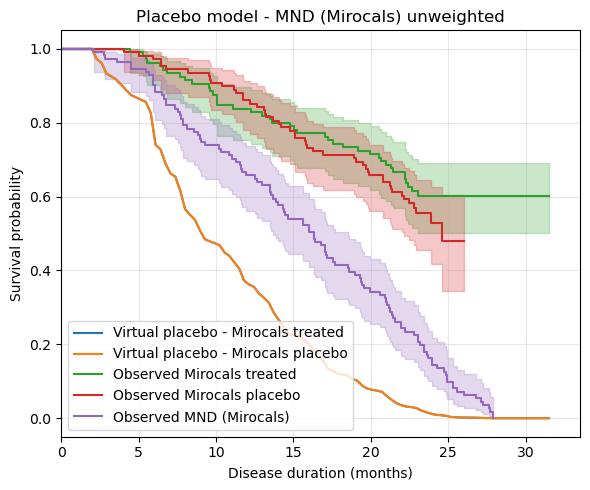

In [77]:
dev_placebo_df = prep_df(popn_pla.copy(), covariates, weight_col=weight_col)
trial_treated_df = prep_df(trial_trt.copy(), covariates, weight_col=weight_col)
trial_placebo_df = prep_df(trial_pla.copy(), covariates, weight_col=weight_col)
reg_placebo_df = prep_df(popn_pla.copy(), covariates, weight_col=weight_col)

model_placebo, dev_placebo_used = fit_cox_model(
    dev_placebo_df,
    covariates=res_strategy.best_vars_full,
    weight_col=weight_col,
    time_col="Disease_Duration",
    event_col="Event",
    robust=True,
)

time_max = max(dev_placebo_used["Disease_Duration"].max(), trial_treated_df["Disease_Duration"].max())
time_grid = np.linspace(0.05, time_max, 100)

shrinkage = uniform_shrinkage_from_slope(res_strategy.slope_corr)

plot_virtual_placebo_vs_treated_and_placebo(
    model_placebo = model_placebo,
    trial_treated_df = trial_treated_df,
    trial_placebo_df = trial_placebo_df,
    reg_placebo_df = reg_placebo_df,
    vars_final = res_strategy.best_vars_full,
    time_grid = time_grid,
    shrinkage = shrinkage,
    x_max = time_max + 2,
    weight_col = weight_col,
    model_data='- MND (Mirocals) unweighted',
    applied_trial_trt='Mirocals treated',
    applied_trial_pla='Mirocals placebo',
    obs_trial_treated='Mirocals treated',
    obs_trial_placebo = "Mirocals placebo",
    obs_reg_placebo='MND (Mirocals)',
    fig_max = 6,
    fig_min = 5,
)


can you extract all the mathematical expressions and its how and why. make this into a comprehensive lecture note. Also include how the weighting works. make it such that any question i am asked i can answer it. make sure to explain every single fucntion

In [ ]:
# hist_placebo_df = prep_df(dat_set.copy(), covariates, weight_col=weight_col)
# obs_treated_df  = prep_df(ext_df.copy(), covariates, weight_col=weight_col)
# obs_placebo_df  = prep_df(dat_set.copy(), covariates, weight_col=weight_col)

# time_max = hist_placebo_df["Disease_Duration"].max()
# time_max = hist_placebo_df["Disease_Duration"].max()
# time_grid = np.linspace(0.05, time_max, 100)  # avoid 0 exactly sometimes

# print(obs_treated_df.columns)
# print(obs_placebo_df.columns)

In [ ]:
# cal_updated = res_ext["calibration_table_updated"]
# display(tidy_calibration_table(cal_updated))

# fig, ax = plot_calibration_table(
#     cal_updated,
#     title=f"External calibration at {t0_months} months (baseline-updated)",
#     percent=True,
#     show_45deg=True
# )
# plt.show()

In [ ]:
# cal_frozen = res_ext["calibration_table_frozen"]
# display(tidy_calibration_table(cal_frozen))

# fig, ax = plot_calibration_table(
#     cal_frozen,
#     title=f"External calibration at {t0_months} months",
#     percent=True,
#     show_45deg=True
# )
# plt.show()

### **Does Being in a trial improve survival or Healthier patients are selected into trials?**

In [ ]:
# df_mnd_lica_trt,df_mnd_lica_pla, df_mnd_miro_trt, df_mnd_miro_pla, 

# df_proact_lica_trt, df_proact_lica_pla, df_proact_miro_trt, df_proact_miro_pla, 

# df_mnd_proact_miro_trt, df_mnd_proact_miro_pla, df_mnd_proact_lica_trt,  df_mnd_proact_lica_pla,

#### ***Raw survival gap: unadjusted comparison***

In [80]:
combined_elig = df_mnd_lica_pla
combined_elig.head(2)

# combined_elig[combined_elig["data"] == "MND_miro"]

,subject_id,Event,Disease_Duration,Study_Arm_Placebo,Age,Diagnostic_Delay,Sex_Male,Onset_Limb,Enrollment_Delay,data,Group,ps,ps_logit,weight
0,P01001,0,30.958607,1,-0.482182,-0.933100,1,1,-0.261098,lical0_pla,1,0.678927,0.748846,0.321073
1,P01002,1,27.562418,1,0.238540,-0.095225,0,1,-0.826269,lical0_pla,1,0.557513,0.231075,0.442487


**Raw KM**

In [78]:
# weighted_km_plot(combined_elig, time_col = "Disease_Duration", event_col = "Event",weight_col = None)

In [79]:
# weighted_km_plot(combined_elig, time_col = "Disease_Duration", event_col = "Event",weight_col = "weight")

**Raw Cox**

In [ ]:
# cph = CoxPHFitter()
# cph.fit(
#     combined_elig[["Disease_Duration", "Event", "Group"]],
#     duration_col="Disease_Duration",
#     event_col="Event"
# )
# cph.summary

**Model sequence**

In [96]:
combined_elig = df_mnd_miro_pla
combined_elig.head(2)

# raw gap
vars_m0 = ["Group"]

# demographics
vars_m1 = ["Group", "Age", "Sex_Male"]

# disease history
vars_m2 = ["Group", "Age", "Sex_Male", "Diagnostic_Delay", "Onset_Limb"]

# disease history_2
vars_m3 = ["Group", "Age", "Sex_Male", "Diagnostic_Delay", "Onset_Limb", "Enrollment_Delay"]

In [97]:
def fit_trial_gap(df, covariates, weight_col=None, entry_col=None):
    cols = ["Disease_Duration", "Event"] + covariates
    if weight_col is not None:
        cols.append(weight_col)
    if entry_col is not None:
        cols.append(entry_col)

    d = df[cols].dropna().copy()

    cph = CoxPHFitter()
    fit_kwargs = dict(
        df=d,
        duration_col="Disease_Duration",
        event_col="Event",
        robust=(weight_col is not None)
    )
    if weight_col is not None:
        fit_kwargs["weights_col"] = weight_col
    if entry_col is not None:
        fit_kwargs["entry_col"] = entry_col

    cph.fit(**fit_kwargs)
    return cph


def sequential_trial_gap_models(
    df,
    model_dict,
    time_col="Disease_Duration",
    event_col="Event",
    weight_col=None,
    entry_col=None
):
    out = []

    for model_name, covs in model_dict.items():
        cols = [time_col, event_col] + covs
        if weight_col:
            cols.append(weight_col)
        if entry_col:
            cols.append(entry_col)

        d = df[cols].dropna().copy()
        cph = CoxPHFitter()
        fit_kwargs = dict(
            df=d,
            duration_col=time_col,
            event_col=event_col,
            robust=(weight_col is not None)
        )
        if weight_col:
            fit_kwargs["weights_col"] = weight_col
        if entry_col:
            fit_kwargs["entry_col"] = entry_col

        cph.fit(**fit_kwargs)

        row = cph.summary.loc["Group"]
        out.append({
            "model": model_name,
            "coef": row["coef"],
            "hr": row["exp(coef)"],
            "ci_lo": row["exp(coef) lower 95%"],
            "ci_hi": row["exp(coef) upper 95%"],
            "p": row["p"]
        })

    return pd.DataFrame(out)

In [ ]:
models = {}
for name, covs in {
    "M0_raw": vars_m0,
    "M1_demo": vars_m1,
    "M2_history": vars_m2,
    "M3_history": vars_m3
}.items():
    models[name] = fit_trial_gap(
        combined_elig,
        covariates=covs,
        weight_col=None,
        entry_col=None
    )

res = sequential_trial_gap_models(
    df=combined_elig,
    model_dict={
        "M0": ["Group"],
        "M1": ["Group", "Age", "Sex_Male"],
        "M2": ["Group", "Age", "Sex_Male", "Diagnostic_Delay", "Onset_Limb"],
        "M3": ["Group", "Age", "Sex_Male", "Diagnostic_Delay", "Onset_Limb", "Enrollment_Delay"]
    },
    weight_col=None,
    entry_col=None
)

res["HR"]  = res["hr"].round(2)
res["LCI"] = res["ci_lo"].round(2)
res["UCI"] = res["ci_hi"].round(2)

label_map = {
    "M0": "M0: None",
    "M1": "M1: + Age, Sex",
    "M2": "M2: + Diagnostic Delay, Onset (Limb)",
    "M3": "M3: + Diagnostic Delay, Onset (Limb), Enrollment Delay"
}

res["Adjustment set"] = res["model"].map(label_map)

final_table = res[["model", "Adjustment set", "HR", "LCI", "UCI", "p"]]
# final_table.to_excel("/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/Results/df_mnd_miro_pla_sequential_trial_gap_unweighted.xlsx")
final_table

,model,Adjustment set,HR,LCI,UCI,p
0,M0,M0: None,0.38,0.27,0.53,3.705480e-08
1,M1,"M1: + Age, Sex",0.36,0.25,0.51,8.996624e-09
2,M2,"M2: + Diagnostic Delay, Onset (Limb)",0.35,0.25,0.50,6.326528e-09
3,M3,"M3: + Diagnostic Delay, Onset (Limb), Enrollme...",0.07,0.01,1.07,5.585782e-02


In [ ]:
models = {}
for name, covs in {
    "M0_raw": vars_m0,
    "M1_demo": vars_m1,
    "M2_history": vars_m2,
    "M3_history": vars_m3
}.items():
    models[name] = fit_trial_gap(
        combined_elig,
        covariates=covs,
        weight_col="weight",
        entry_col=None
    )

res = sequential_trial_gap_models(
    df=combined_elig,
    model_dict={
        "M0": ["Group"],
        "M1": ["Group", "Age", "Sex_Male"],
        "M2": ["Group", "Age", "Sex_Male", "Diagnostic_Delay", "Onset_Limb"],
        "M3": ["Group", "Age", "Sex_Male", "Diagnostic_Delay", "Onset_Limb", "Enrollment_Delay"]
    },
    weight_col="weight",
    entry_col=None
)

res["HR"]  = res["hr"].round(2)
res["LCI"] = res["ci_lo"].round(2)
res["UCI"] = res["ci_hi"].round(2)

label_map = {
    "M0": "M0: None",
    "M1": "M1: + Age, Sex",
    "M2": "M2: + Diagnostic Delay, Onset (Limb)",
    "M3": "M3: + Diagnostic Delay, Onset (Limb), Enrollment Delay"
}

res["Adjustment set"] = res["model"].map(label_map)

final_table_weight = res[["model", "Adjustment set", "HR", "LCI", "UCI", "p"]]
# final_table_weight.to_excel("/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/Results/df_mnd_miro_pla_sequential_trial_gap_weighted.xlsx")
final_table_weight

,model,Adjustment set,HR,LCI,UCI,p
0,M0,M0: None,0.68,0.47,0.97,0.033286
1,M1,"M1: + Age, Sex",0.67,0.47,0.97,0.034010
2,M2,"M2: + Diagnostic Delay, Onset (Limb)",0.68,0.48,0.98,0.038759
3,M3,"M3: + Diagnostic Delay, Onset (Limb), Enrollme...",0.14,0.01,3.52,0.231338


***Balance diagnostics: show SMD before and after weighting***

In [ ]:
# df_mnd_lica_trt,df_mnd_lica_pla, df_mnd_miro_trt, df_mnd_miro_pla, 

# df_proact_lica_trt, df_proact_lica_pla, df_proact_miro_trt, df_proact_miro_pla, 

# df_mnd_proact_miro_trt, df_mnd_proact_miro_pla, df_mnd_proact_lica_trt,  df_mnd_proact_lica_pla,